# Разработка решения для компании «Работа с заботой» с целью выяснения причин оттока сотрудников

HR-аналитики компании «Работа с заботой» помогают бизнесу оптимизировать управление персоналом: бизнес предоставляет данные, а аналитики предлагают, как избежать финансовых потерь и оттока сотрудников. В этом HR-аналитикам пригодится машинное обучение, с помощью которого получится быстрее и точнее отвечать на вопросы бизнеса.

Компания предоставила данные с характеристиками сотрудников компании. Среди них — уровень удовлетворённости сотрудника работой в компании. Эту информацию получили из форм обратной связи: сотрудники заполняют тест-опросник, и по его результатам рассчитывается доля их удовлетворённости от 0 до 1, где 0 — совершенно неудовлетворён, 1 — полностью удовлетворён. 

Компания предоставила данные с характеристиками сотрудников компании. Среди них — уровень удовлетворённости сотрудника работой в компании. Эту информацию получили из форм обратной связи: сотрудники заполняют тест-опросник, и по его результатам рассчитывается доля их удовлетворённости от 0 до 1, где 0 — совершенно неудовлетворён, 1 — полностью удовлетворён. 

**Формирование задачи**

Поставлено несколько задач. Первая — построить модель, которая сможет предсказать уровень удовлетворённости сотрудника на основе данных заказчика. 

Для этой задачи заказчик предоставил данные с признаками:

| Показатель            | Описание                                                                  |
|-----------------------|---------------------------------------------------------------------------|
| **id**                    | уникальный идентификатор сотрудника                                       |
| **dept**                  | отдел, в котором работает сотрудник                                       |
| **level**                 | уровень занимаемой должности                                              |
| **workload**              | уровень загруженности сотрудника                                          |
| **employment_years**      | длительность работы в компании (в годах)                                  |
| **last_year_promo**       | показывает, было ли повышение за последний год                            |
| **last_year_violations**  | показывает, нарушал ли сотрудник трудовой договор за последний год        |
| **supervisor_evaluation** | оценка качества работы сотрудника, которую дал руководитель               |
| **salary**                | ежемесячная зарплата сотрудника                                           |
| **job_satisfaction_rate** | уровень удовлетворённости сотрудника работой в компании, целевой признак  |


Почему бизнесу это важно: удовлетворённость работой напрямую влияет на отток сотрудников. А предсказание оттока — одна из важнейших задач HR-аналитиков. Внезапные увольнения несут в себе риски для компании, особенно если уходит важный сотрудник.

Вторая задача — построить модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании. Целевой признак отличается: это **quit** — увольнение сотрудника из компании.

**План исследования**

- **Задача №1: предсказание уровня удовлетворённости сотрудника**
  - Загрузка и предообработка данных
  - Исследовательский анализ данных
  - Подготовка данных
  - Обучение моделей
  - Анализ признаков
  - Оформление выводов
- **Задача №2: предсказание увольнения сотрудника из компании**
  - Загрузка и предообработка данных
  - Исследовательский анализ данных
  - Добавление нового входного признака
  - Подготовка данных
  - Обучение моделей
  - Анализ признаков
  - Выводы
- **Общий вывод**

**Описание данных**

Данные для работы над задачей №1 находятся в нескольких датасетах:

- Тренировочная выборка: train_job_satisfaction_rate.csv
- Входные признаки тестовой выборки: test_features.csv
- Целевой признак тестовой выборки: test_target_job_satisfaction_rate.csv

Данные для работы над задачей №2 находятся в нескольких датасетах:

- Тренировочная выборка: train_quit.csv
- Входные признаки тестовой выборки те же, что и в прошлой задаче: test_features.csv
- Целевой признак тестовой выборки: test_target_quit.csv

# Задача 1: предсказание уровня удовлетворённости сотрудника

## Шаг. Загрузка и предобработка данных для задачи №1

In [1]:
!pip install --upgrade scikit-learn -q
!pip install matplotlib==3.5.1
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
!pip install phik -q
import phik 
from phik import phik_matrix
from phik.report import plot_correlation_matrix
RANDOM_STATE = 42
TEST_SIZE = 0.25
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler,\
StandardScaler, RobustScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.model_selection import train_test_split, GridSearchCV,\
RandomizedSearchCV, cross_val_score
from sklearn.metrics import make_scorer, roc_auc_score, accuracy_score, f1_score, r2_score
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.inspection import permutation_importance
!pip install shap -q
import sklearn
import shap
import random
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
#считаем csv - файл с данными `test_features.csv`
try:
    test_features = pd.read_csv('test_features.csv')
except:
    test_features = pd.read_csv('https://code.s3.yandex.net/datasets/test_features.csv')

#считаем csv - файл с данными `test_target_job_satisfaction_rate.csv`
try:
    test_target_job_satisfaction_rate = pd.read_csv('test_target_job_satisfaction_rate.csv')
except:
    test_target_job_satisfaction_rate = \
    pd.read_csv('https://code.s3.yandex.net/datasets/test_target_job_satisfaction_rate.csv')
    
#считаем csv - файл с данными `train_job_satisfaction_rate.csv`
try:
    train_job_satisfaction_rate = pd.read_csv('train_job_satisfaction_rate.csv')
except:
    train_job_satisfaction_rate = \
    pd.read_csv('https://code.s3.yandex.net/datasets/train_job_satisfaction_rate.csv')

### Предобработка данных для датасета 'test_features'

In [3]:
def desc_data(data): #создадим функцию для описания датасетов
    display(data.head(10)) 
    list_c = data.columns
    print(data.info())
    print('-'* 25)
    print('Количество полных дубликатов ', data.duplicated().sum())
    for col_l in list_c:
        print('-'* 25)
        print(col_l,': кол-во NaN',data[col_l].isna().sum(),\
              ', процент NaN', round(data[col_l].isna().mean()*100,2),'%')
        print(data[col_l].describe())

In [4]:
desc_data(test_features)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800
5,429973,purchasing,middle,medium,6,no,no,3,42000
6,850699,technology,junior,medium,3,no,no,3,26400
7,500791,sales,middle,high,9,no,no,4,49200
8,767867,marketing,middle,high,3,no,yes,4,62400
9,937235,sales,junior,medium,1,no,yes,3,26400


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     2000 non-null   int64 
 1   dept                   1998 non-null   object
 2   level                  1999 non-null   object
 3   workload               2000 non-null   object
 4   employment_years       2000 non-null   int64 
 5   last_year_promo        2000 non-null   object
 6   last_year_violations   2000 non-null   object
 7   supervisor_evaluation  2000 non-null   int64 
 8   salary                 2000 non-null   int64 
dtypes: int64(4), object(5)
memory usage: 140.8+ KB
None
-------------------------
Количество полных дубликатов  0
-------------------------
id : кол-во NaN 0 , процент NaN 0.0 %
count      2000.000000
mean     552765.213500
std      253851.326129
min      100298.000000
25%      339052.000000
50%      550793.000000
75%      765763.

| Показатель            | Описание                                                           | Формат | Примечание               |
|-----------------------|--------------------------------------------------------------------|--------|--------------------------|
| **id**                    | уникальный идентификатор сотрудника                                | int64  | Формат данных оптимален  |
| **dept**                  | отдел, в котором работает сотрудник                                | object | Формат данных оптимален  |
| **level**                 | уровень занимаемой должности                                       | object | Формат данных оптимален  |
| **workload**              | уровень загруженности сотрудника                                   | object | Формат данных оптимален  |
| **employment_years**      | длительность работы в компании (в годах)                           | int64  | Формат данных оптимален  |
| **last_year_promo**       | показывает, было ли повышение за последний год                     | object | Формат данных оптимален  |
| **last_year_violations**  | показывает, нарушал ли сотрудник трудовой договор за последний год | object | Формат данных оптимален  |
| **supervisor_evaluation** | оценка качества работы сотрудника, которую дал руководитель        | int64  | Формат данных оптимален  |
| **salary**                | ежемесячная зарплата сотрудника                                    | int64  | Формат данных оптимален  |

In [5]:
test_features.describe()

,id,employment_years,supervisor_evaluation,salary
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,552765.213500,3.666500,3.526500,34066.800000
std,253851.326129,2.537222,0.996892,15398.436729
min,100298.000000,1.000000,1.000000,12000.000000
25%,339052.000000,1.000000,3.000000,22800.000000
50%,550793.000000,3.000000,4.000000,30000.000000
75%,765763.750000,6.000000,4.000000,43200.000000
max,999029.000000,10.000000,5.000000,96000.000000


Проверим уникальные значения для категориальных признаков.

In [6]:
def unique_znach(data): #функция для вывода уникальных значений
    list_c = data.select_dtypes(include='object').columns.tolist()
    for i in list_c:
        print('Уникальные значения для столбца "',i,'" :')
        print(data[i].unique())
        print('-'* 25)

In [7]:
unique_znach(test_features)

Уникальные значения для столбца " dept " :
['marketing' 'hr' 'sales' 'purchasing' 'technology' nan ' ']
-------------------------
Уникальные значения для столбца " level " :
['junior' 'middle' 'sinior' nan]
-------------------------
Уникальные значения для столбца " workload " :
['medium' 'low' 'high' ' ']
-------------------------
Уникальные значения для столбца " last_year_promo " :
['no' 'yes']
-------------------------
Уникальные значения для столбца " last_year_violations " :
['no' 'yes']
-------------------------


Либо некоторые сотрудники не посчитали необходимым заполнить данные по разделам 'dept', 'level' и 'workload', либо это техническая ошибка при формировании датасета. Необходимо будет учесть это при построении модели.

Для этого заменим пропуски на значение Nan.

In [8]:
test_features = test_features.replace(to_replace=' ', value=np.nan)

In [9]:
unique_znach(test_features)

Уникальные значения для столбца " dept " :
['marketing' 'hr' 'sales' 'purchasing' 'technology' nan]
-------------------------
Уникальные значения для столбца " level " :
['junior' 'middle' 'sinior' nan]
-------------------------
Уникальные значения для столбца " workload " :
['medium' 'low' 'high' nan]
-------------------------
Уникальные значения для столбца " last_year_promo " :
['no' 'yes']
-------------------------
Уникальные значения для столбца " last_year_violations " :
['no' 'yes']
-------------------------


### Предобработка данных для датасета 'test_target_job_satisfaction_rate'

In [10]:
desc_data(test_target_job_satisfaction_rate)

,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08
5,817219,0.76
6,269033,0.64
7,962356,0.38
8,649052,0.14
9,532834,0.59


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2000 non-null   int64  
 1   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 31.4 KB
None
-------------------------
Количество полных дубликатов  0
-------------------------
id : кол-во NaN 0 , процент NaN 0.0 %
count      2000.000000
mean     552765.213500
std      253851.326129
min      100298.000000
25%      339052.000000
50%      550793.000000
75%      765763.750000
max      999029.000000
Name: id, dtype: float64
-------------------------
job_satisfaction_rate : кол-во NaN 0 , процент NaN 0.0 %
count    2000.00000
mean        0.54878
std         0.22011
min         0.03000
25%         0.38000
50%         0.58000
75%         0.72000
max         1.00000
Name: job_satisfaction_rate, dtype: float64


| Показатель            | Описание                                                                 | Формат  | Примечание               |
|-----------------------|--------------------------------------------------------------------------|---------|--------------------------|
| **id**                    | уникальный идентификатор сотрудника                                      | int64   | Формат данных оптимален  |
| **job_satisfaction_rate** | уровень удовлетворённости сотрудника работой в компании, целевой признак | float64 | Формат данных оптимален  |

### Объединение датасетов 'test_features' и 'test_target_job_satisfaction_rate'

Объединим датасеты для решения задачи построения модели.

In [11]:
test_df_rate = pd.merge(test_features, test_target_job_satisfaction_rate, on='id')

In [12]:
test_df_rate.shape

(2000, 10)

### Предобработка данных для датасета 'train_job_satisfaction_rate'

In [13]:
desc_data(train_job_satisfaction_rate)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20
5,405448,hr,middle,low,7,no,no,4,30000,0.78
6,857135,sales,sinior,medium,9,no,no,3,56400,0.56
7,400657,purchasing,middle,high,9,no,no,3,52800,0.44
8,198846,hr,junior,low,1,no,no,2,13200,0.14
9,149797,technology,middle,high,6,no,no,3,54000,0.47


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB
None
-------------------------
Количество полных дубликатов  0
-------------------------
id : кол-во NaN 0 , процент NaN 0.0 %
count      4000.000000
mean     544957.621000
std      257883.104622
min      

| Показатель            | Описание                                                                 | Формат  | Примечание               |
|-----------------------|--------------------------------------------------------------------------|---------|--------------------------|
| **id**                    | уникальный идентификатор сотрудника                                      | int64   | Формат данных оптимален  |
| **dept**                  | отдел, в котором работает сотрудник                                      | object  | Формат данных оптимален  |
| **level**                 | уровень занимаемой должности                                             | object  | Формат данных оптимален  |
| **workload**              | уровень загруженности сотрудника                                         | object  | Формат данных оптимален  |
| **employment_years**      | длительность работы в компании (в годах)                                 | int64   | Формат данных оптимален  |
| **last_year_promo**       | показывает, было ли повышение за последний год                           | object  | Формат данных оптимален  |
| **last_year_violations**  | показывает, нарушал ли сотрудник трудовой договор за последний год       | object  | Формат данных оптимален  |
| **supervisor_evaluation** | оценка качества работы сотрудника, которую дал руководитель              | int64   | Формат данных оптимален  |
| **salary**                | ежемесячная зарплата сотрудника                                          | int64   | Формат данных оптимален  |
| **job_satisfaction_rate** | уровень удовлетворённости сотрудника работой в компании, целевой признак | float64 | Формат данных оптимален  |


In [14]:
train_job_satisfaction_rate.describe()

,id,employment_years,supervisor_evaluation,salary,job_satisfaction_rate
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,544957.621000,3.718500,3.476500,33926.700000,0.533995
std,257883.104622,2.542513,1.008812,14900.703838,0.225327
min,100954.000000,1.000000,1.000000,12000.000000,0.030000
25%,322836.750000,2.000000,3.000000,22800.000000,0.360000
50%,534082.500000,3.000000,4.000000,30000.000000,0.560000
75%,771446.000000,6.000000,4.000000,43200.000000,0.710000
max,999521.000000,10.000000,5.000000,98400.000000,1.000000


Проверим уникальные значения для категориальных признаков.

In [15]:
unique_znach(train_job_satisfaction_rate)

Уникальные значения для столбца " dept " :
['sales' 'hr' 'technology' 'purchasing' 'marketing' nan]
-------------------------
Уникальные значения для столбца " level " :
['junior' 'middle' 'sinior' nan]
-------------------------
Уникальные значения для столбца " workload " :
['medium' 'high' 'low']
-------------------------
Уникальные значения для столбца " last_year_promo " :
['no' 'yes']
-------------------------
Уникальные значения для столбца " last_year_violations " :
['no' 'yes']
-------------------------


Либо некоторые сотрудники не посчитали необходимым заполнить данные по разделам 'dept' и 'level', либо это техническая ошибка при формировании датасета. Необходимо будет учесть это при построении модели.

**<div style="border:solid green 2px; padding: 20px">
Вывод: На 1 шаге были выгружены и изучены данные трех датафреймов. Данные, представленнные в таблицах, соответствуют изначально поставленной задаче. Полных дубликатов нет. Формат данных оптимален. Были объединены датасеты тестовых данных. Пропуски не удалялись, но необходимо будет учесть их наличие при построении модели.**

## Шаг. Исследовательский анализ данных для задачи №1

### Исследовательский анализ данных для датасета 'test_df_rate'

In [16]:
test_df_rate.describe()

,id,employment_years,supervisor_evaluation,salary,job_satisfaction_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000
mean,552765.213500,3.666500,3.526500,34066.800000,0.54878
std,253851.326129,2.537222,0.996892,15398.436729,0.22011
min,100298.000000,1.000000,1.000000,12000.000000,0.03000
25%,339052.000000,1.000000,3.000000,22800.000000,0.38000
50%,550793.000000,3.000000,4.000000,30000.000000,0.58000
75%,765763.750000,6.000000,4.000000,43200.000000,0.72000
max,999029.000000,10.000000,5.000000,96000.000000,1.00000


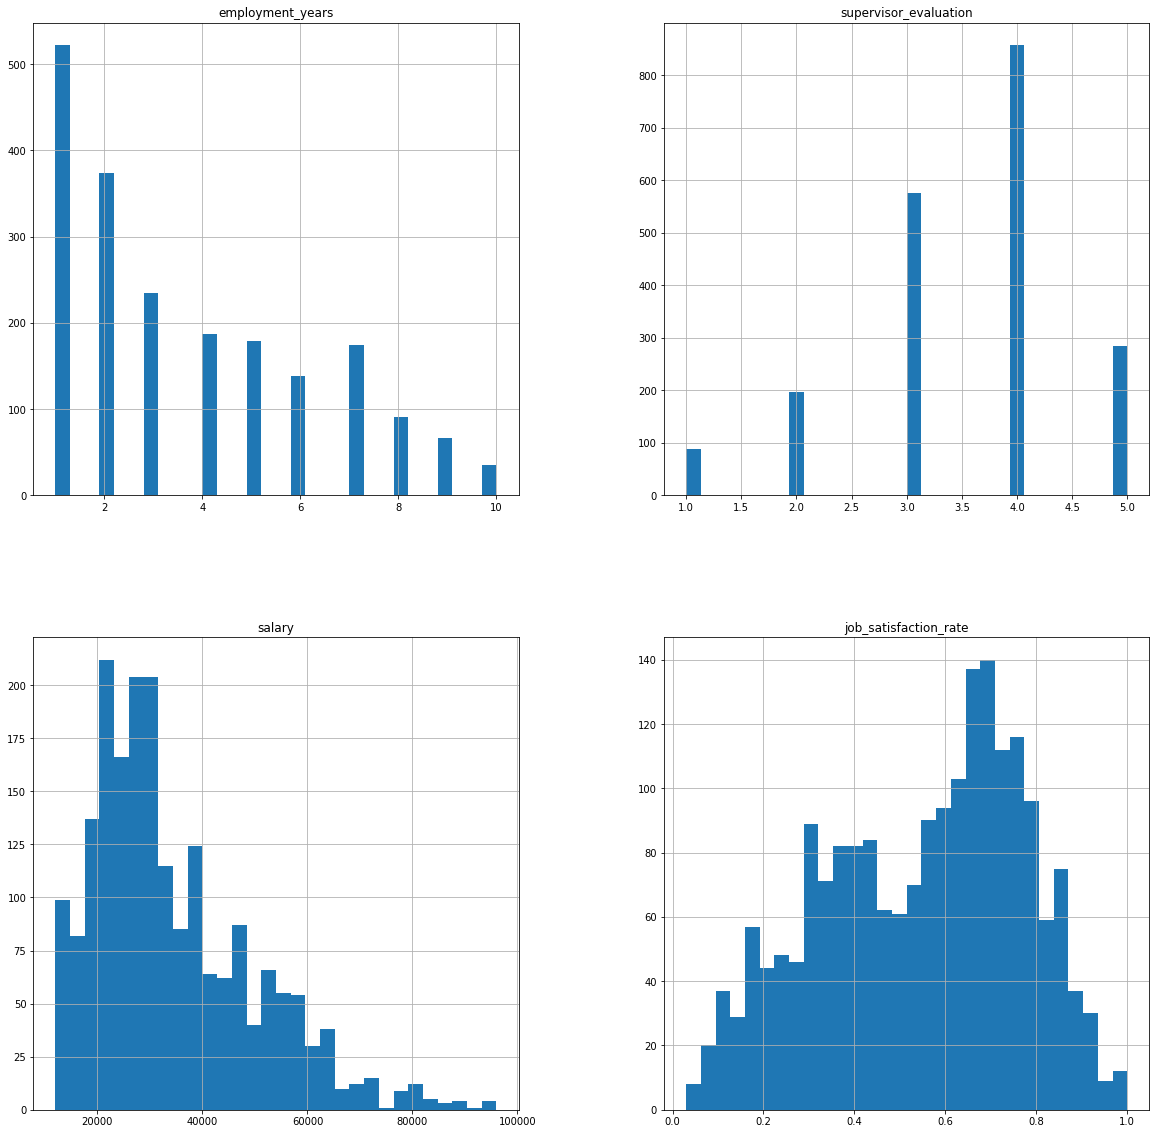

In [17]:
test_df_rate.drop('id', axis=1).hist(figsize=(20, 20),bins=30);

Выбросов не наблюдается.

Проанализируем категориальные признаки (на данном этапе пробелы в данных не рассматриваются).

In [18]:
def pie_market(data):
    list_c = data.select_dtypes(include='object').columns.tolist()
    for index in list_c:
        str = index
        print ('\033[1m' +str.center(100))
        table = data.pivot_table(index=index, values='id', aggfunc='count')
        table.columns = ['Количество']
        display(table.sort_values('Количество',ascending=False))
        ax = table.plot(kind='pie', y='Количество', autopct='%1.1f%%', figsize=(4,4));
        ax.get_legend().remove()
        plt.ylabel('')
        plt.title('Рапределение сотрудников по показателю "' + index + '"')

                                                dept                                                


,Количество
dept,
sales,763
technology,455
marketing,279
purchasing,273
hr,227


                                               level                                                


,Количество
level,
junior,974
middle,854
sinior,171


                                              workload                                              


,Количество
workload,
medium,1043
low,593
high,363


                                          last_year_promo                                           


,Количество
last_year_promo,
no,1937
yes,63


                                        last_year_violations                                        


,Количество
last_year_violations,
no,1738
yes,262


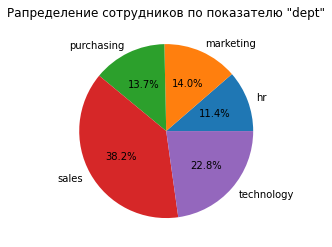

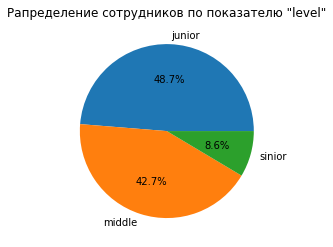

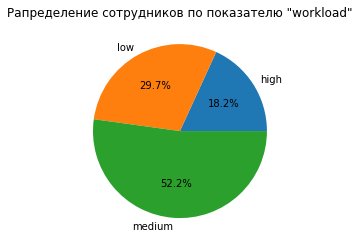

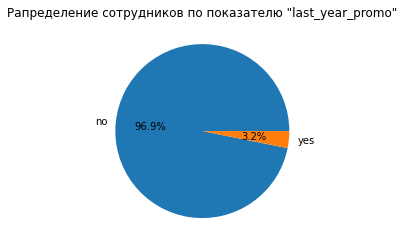

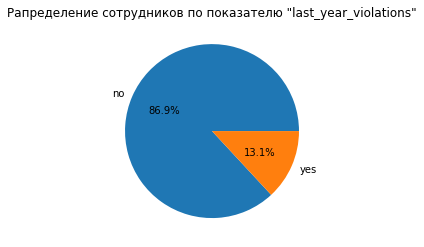

In [19]:
pie_market(test_df_rate)

Проанализируем количественные признаки.

In [20]:
def hist_plot(data,index,bins):
    plt.figure(figsize=(20, 5))
    plt.suptitle('Гистограмма и диаграмма размаха для показателя "' + index+'"', fontsize=20, y=1.05)
        
    
    plt.subplot(1, 2, 1)
    mean = np.mean(data[index])
    median = np.median(data[index])
    sns.histplot(data[index], bins=bins, kde=True, color='skyblue')
    plt.axvline(mean, color='r', linestyle='dashed', linewidth=1, label=f'Среднее: {mean:.2f}')
    plt.axvline(median, color='g', linestyle='dashed', linewidth=1, label=f'Медиана: {median:.2f}');
    plt.ylabel('Количество показателей')
    plt.title('Гистограмма по значению ' + index, fontsize=16)
    plt.legend()
    plt.xlabel(index);
    
    plt.subplot(1, 2, 2)
    ax = sns.boxplot(y=index, data=data)
    plt.title('Boxplot для показателя ' + index, fontsize=16)
    plt.axhline(y=mean, color='g', linestyle='--')
    plt.ylabel(index, fontsize=14);
    plt.show()

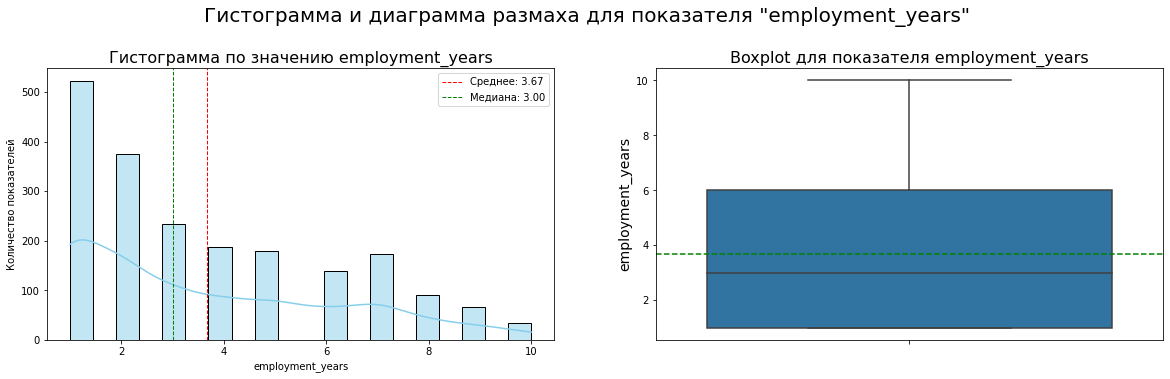

In [21]:
hist_plot(test_df_rate,'employment_years',20)

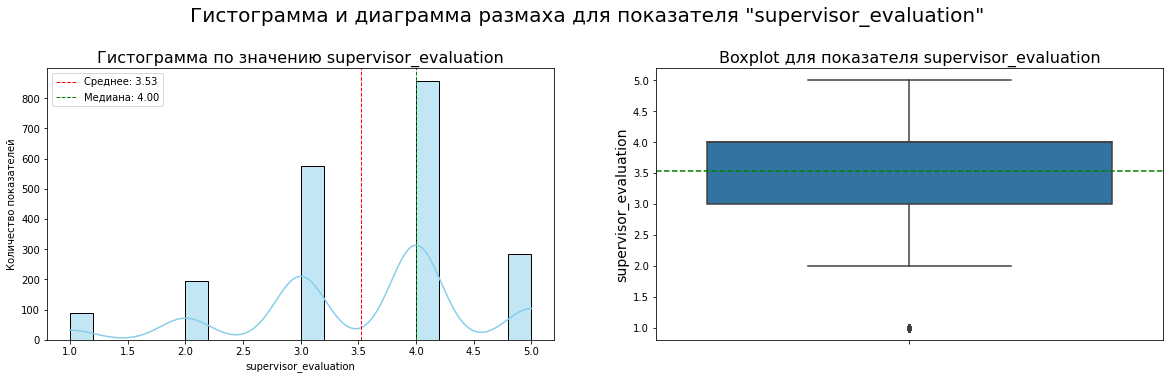

In [22]:
hist_plot(test_df_rate,'supervisor_evaluation',20)

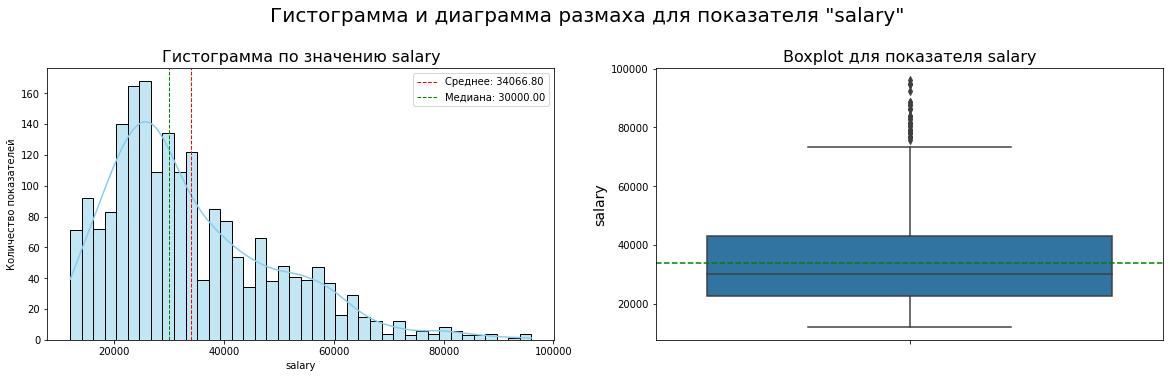

In [23]:
hist_plot(test_df_rate,'salary',40)

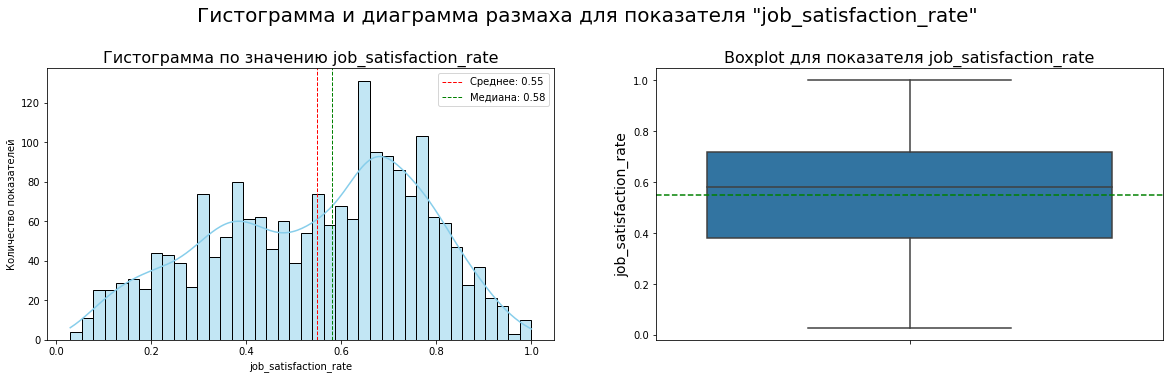

In [24]:
hist_plot(test_df_rate,'job_satisfaction_rate',40)

Пронализируем также распределение показателей в зависимости от удовлетворенности.

In [25]:
test_df_rate_min = test_df_rate.query('job_satisfaction_rate<=0.6')
test_df_rate_max = test_df_rate.query('job_satisfaction_rate>0.6')
print(test_df_rate_min.shape)
print(test_df_rate_max.shape)

(1046, 10)
(954, 10)


In [26]:
def min_max_rate(data_min,data_max):
    list_c = test_df_rate.select_dtypes(include='object').columns.tolist()
    for name in list_c:
        table_min = data_min.pivot_table(index=name, values='id', aggfunc='count').reset_index()
        table_max = data_max.pivot_table(index=name, values='id', aggfunc='count').reset_index()

        fig, axs = plt.subplots(1, 2, figsize=(15, 5))      
        plt.suptitle (name, fontsize=20)
    
        plt.subplot(1, 2, 1)
        plt.title('Менее 0.6', fontsize=15)
        plt.pie(table_min['id'].unique(), autopct='%1.1f%%',radius = 1)
    
        plt.subplot(1, 2, 2)
        plt.title('Более 0.6', fontsize=15)
        plt.pie(table_max['id'].unique(), autopct='%1.1f%%',radius = 1)
        plt.legend(title=name, loc="center right", bbox_to_anchor = (1.5,0,0.5,1),\
                   labels = table_max[name].unique())
    
    list_num = test_df_rate.drop(['id','job_satisfaction_rate'], axis=1).\
    select_dtypes(include=['int64']).columns.tolist()
    for name in list_num:
        mean_min = np.mean(data_min[name])
        median_min = np.median(data_min[name])
        mean_max = np.mean(data_max[name])
        median_max = np.median(data_max[name])
        plt.figure(figsize=(7, 4))
        sns.histplot(data_min[name], bins=70, color='orange', alpha=0.8,\
                     label='Менее 0.6', kde=True)
        plt.axvline(mean_min, color='orange', linestyle='dashed', linewidth=1,\
                    label=f'Среднее для "Менее 0.6": {mean_min:.2f}')
        plt.axvline(median_min, color='red', linestyle='dashed', linewidth=1,\
                    label=f'Медиана для "Менее 0.6": {median_min:.2f}');
        sns.histplot(data_max[name], bins=70, color='aquamarine', alpha=0.8,\
                     label='Более 0.6', kde=True)
        plt.axvline(mean_max, color='blue', linestyle='dashed', linewidth=1,\
                    label=f'Среднее для "Более 0.6": {mean_max:.2f}')
        plt.axvline(median_max, color='green', linestyle='dashed', linewidth=1,\
                    label=f'Медиана для "Более 0.6": {median_max:.2f}');
        plt.legend(title='Удовлетвореность')
        plt.xlabel(name)
        plt.ylabel('Количество значений')
        plt.title('Гистограмма по значениям для "'+name+'"', fontsize=10);

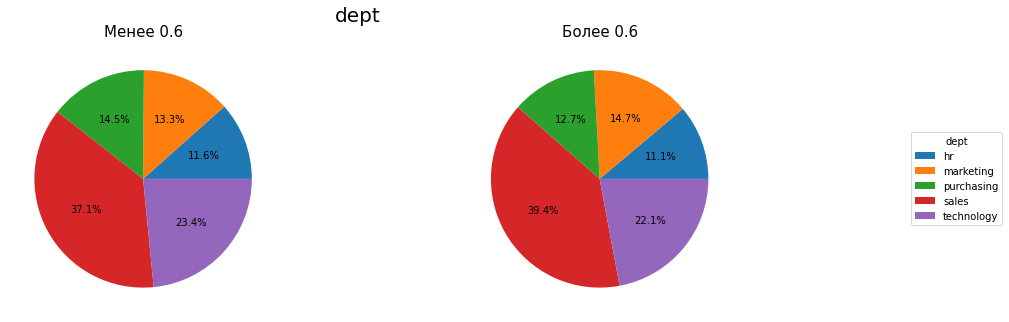

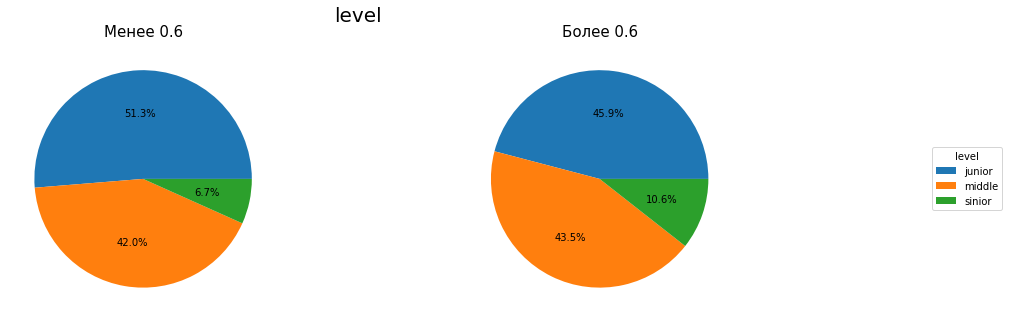

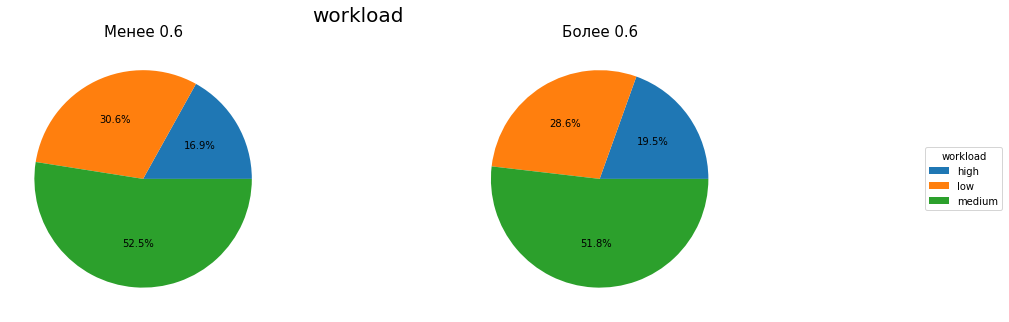

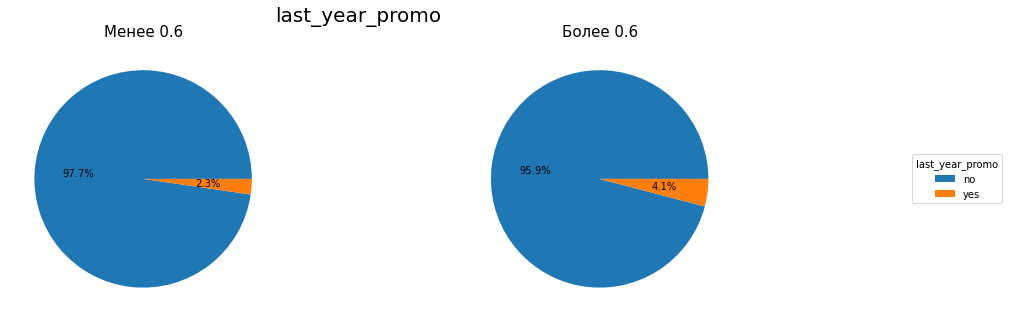

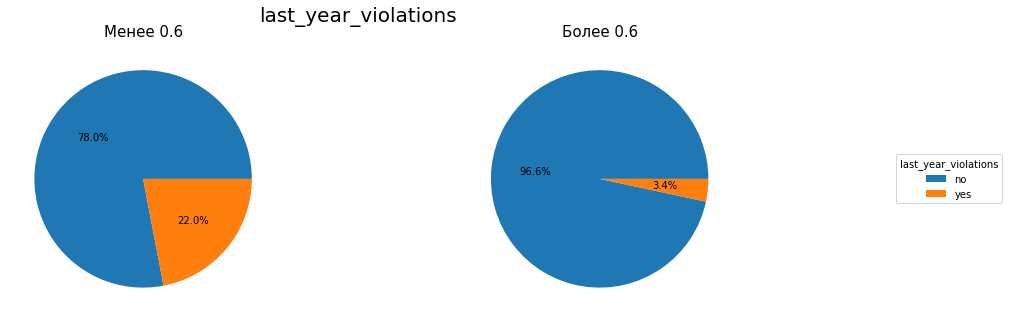

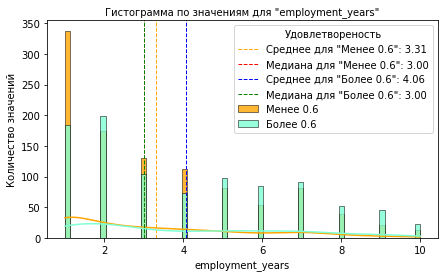

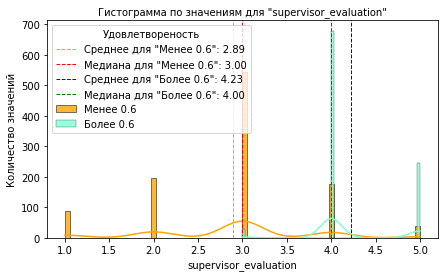

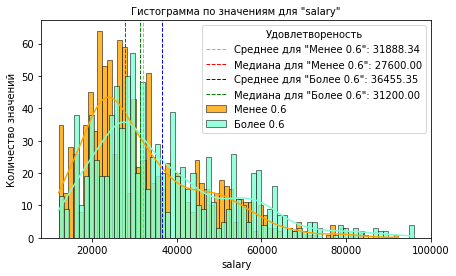

In [27]:
min_max_rate(test_df_rate_min,test_df_rate_max)

Наблюдаются интересные моменты при сопоставлении данных в группе сотрудников с удовлетворенностью менее 0,6 и более 0,6:

- большую часть в группе с менее удовлетворенными сотрудниками занимают сотрудники sales (37,1%), также и среди удовлетворенных работой лидирует sales (продажи) (39,4%).
- по признаку ‘level’ показатели распределения относительно сопоставимы.
- по признаку ‘workload’ показатели распределения относительно сопоставимы.
- вполне логично, что в группе удовлетворенных работой большее количество повышений за последний год.
- в группе неудовлетворенных работой большее количество нарушений трудового договора. Непонятно, является ли это изначально безответственным отношением сотрудника к работе или уже последствием неудовлетворенности.
- по длительности пребывания сотрудников в компании медианные данные сопоставимы.
- у неудовлетворенных работой и среднее, и медианное значение оценки работы значительно меньше, чем в группе удовлетворенных работой. Опять же непонятно, является ли это изначально безответственным отношением сотрудника к работе или уже последствием неудовлетворенности.
- по показателям зарплат группа неудовлетворенных несколько уступает группе удовлетворенных работой.

**Соответственно, необходимо в данном случае выявить сотрудников, которые по мнению руководства изначально менее ответственно подходят к работе, а также тех, чье отношение к работе было изменено в процессе.**

### Исследовательский анализ данных для датасета 'train_job_satisfaction_rate'

In [28]:
train_job_satisfaction_rate.describe()

,id,employment_years,supervisor_evaluation,salary,job_satisfaction_rate
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,544957.621000,3.718500,3.476500,33926.700000,0.533995
std,257883.104622,2.542513,1.008812,14900.703838,0.225327
min,100954.000000,1.000000,1.000000,12000.000000,0.030000
25%,322836.750000,2.000000,3.000000,22800.000000,0.360000
50%,534082.500000,3.000000,4.000000,30000.000000,0.560000
75%,771446.000000,6.000000,4.000000,43200.000000,0.710000
max,999521.000000,10.000000,5.000000,98400.000000,1.000000


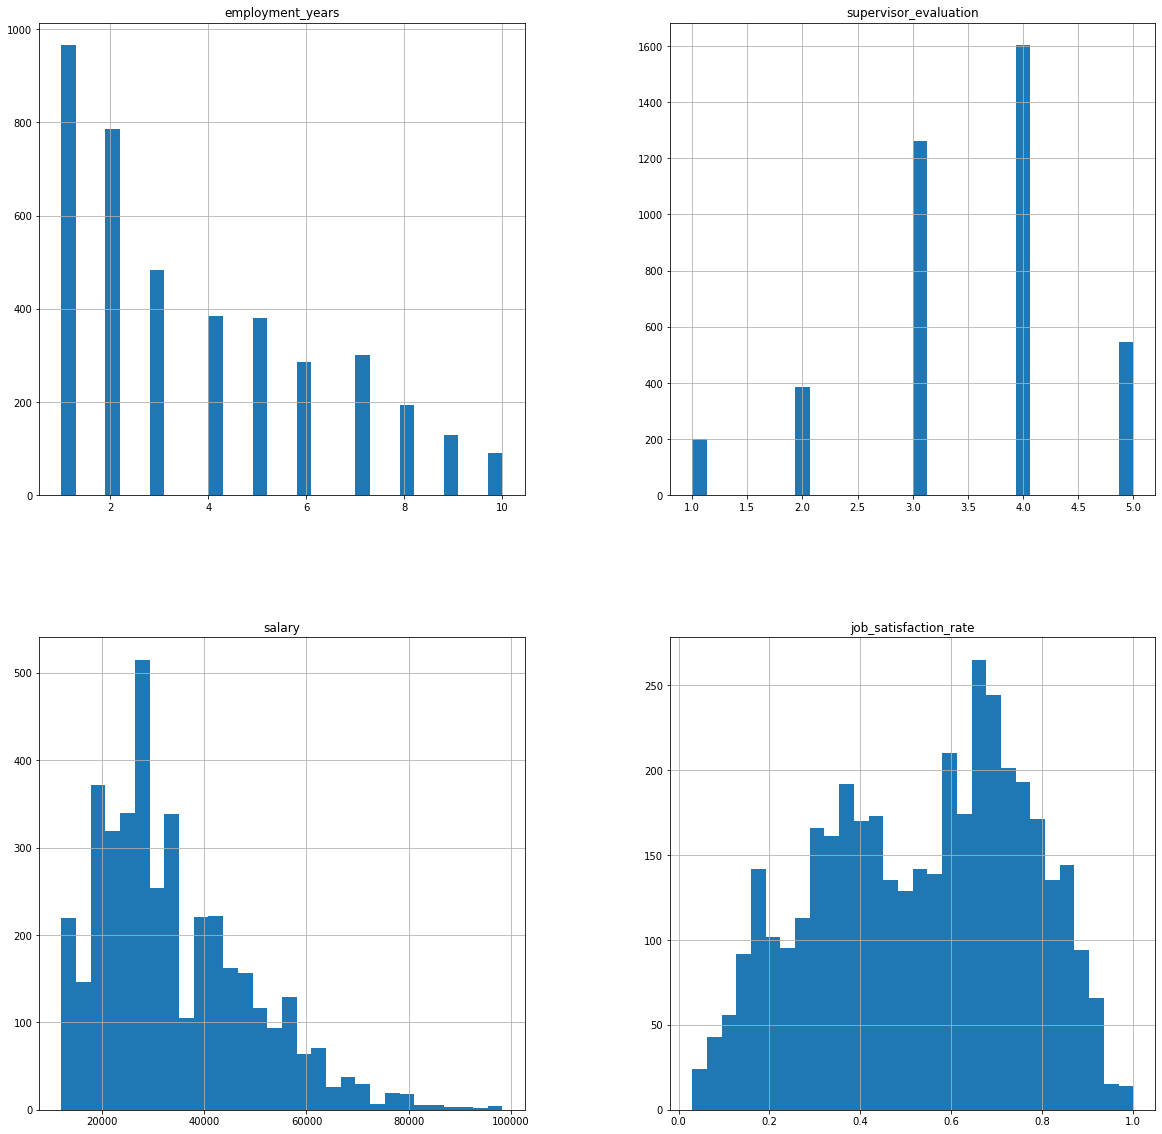

In [29]:
train_job_satisfaction_rate.drop('id', axis=1).hist(figsize=(20, 20),bins=30);

Выбросов не наблюдается.

Проанализируем категориальные признаки.

                                                dept                                                


,Количество
dept,
sales,1512
technology,866
purchasing,610
marketing,550
hr,456


                                               level                                                


,Количество
level,
junior,1894
middle,1744
sinior,358


                                              workload                                              


,Количество
workload,
medium,2066
low,1200
high,734


                                          last_year_promo                                           


,Количество
last_year_promo,
no,3880
yes,120


                                        last_year_violations                                        


,Количество
last_year_violations,
no,3441
yes,559


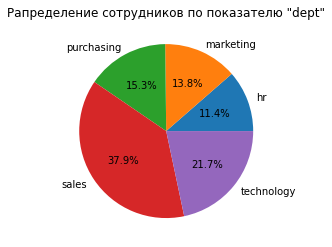

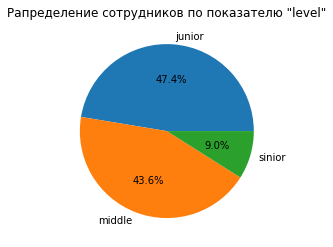

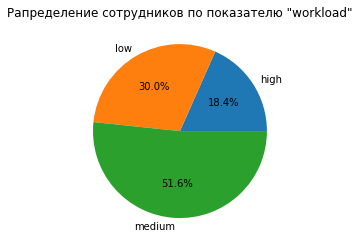

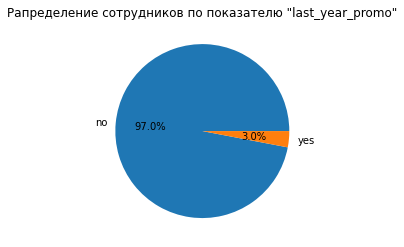

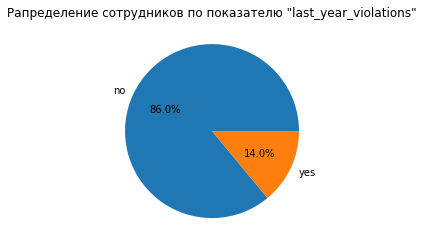

In [30]:
pie_market(train_job_satisfaction_rate)

Проанализируем количественные признаки.

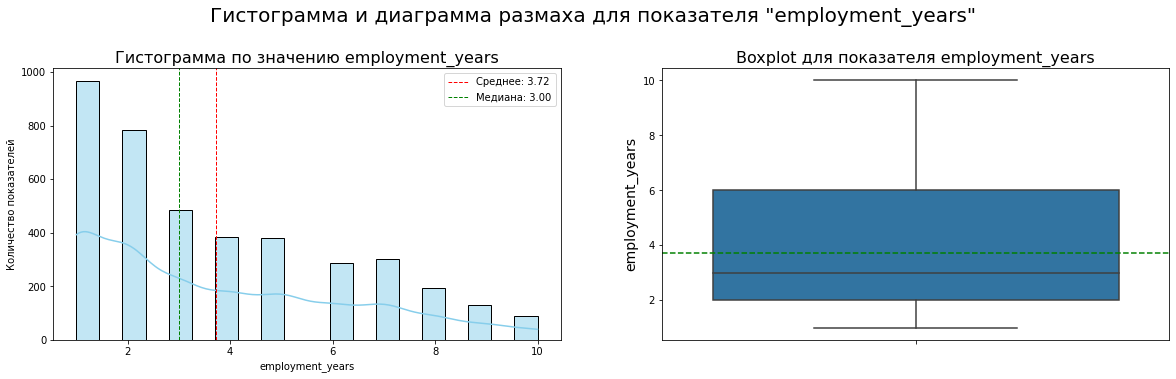

In [31]:
hist_plot(train_job_satisfaction_rate,'employment_years',20)

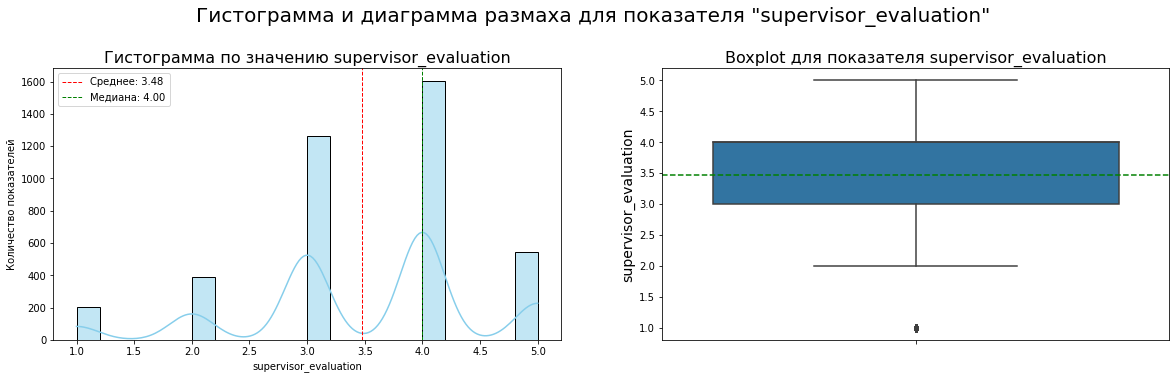

In [32]:
hist_plot(train_job_satisfaction_rate,'supervisor_evaluation',20)

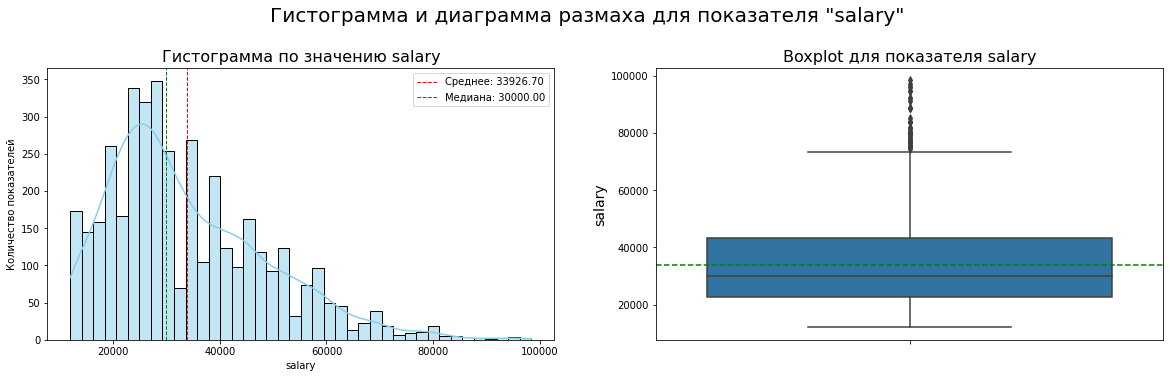

In [33]:
hist_plot(train_job_satisfaction_rate,'salary',40)

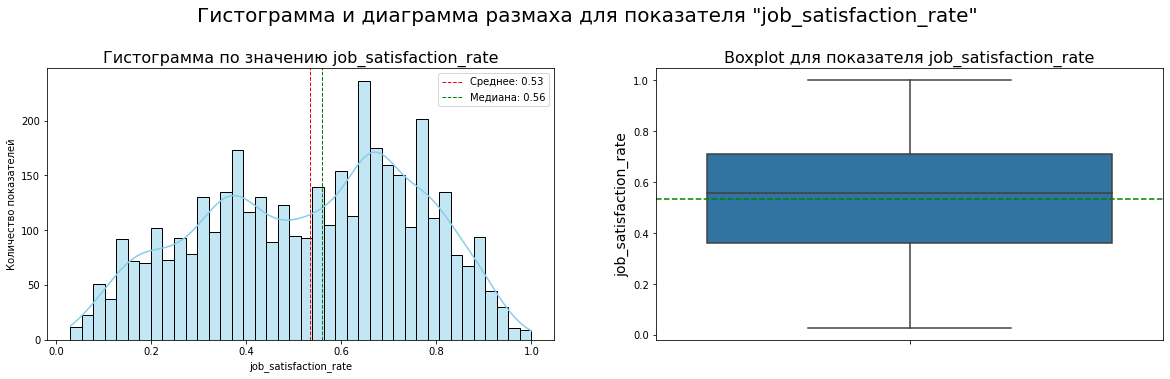

In [34]:
hist_plot(train_job_satisfaction_rate,'job_satisfaction_rate',40)

Посмотрим на картину распределения по степени удовлетворенности в тренировочной выборке.

In [35]:
train_df_rate_min = train_job_satisfaction_rate.query('job_satisfaction_rate<=0.6')
train_df_rate_max = train_job_satisfaction_rate.query('job_satisfaction_rate>0.6')
print(train_df_rate_min.shape)
print(train_df_rate_max.shape)

(2234, 10)
(1766, 10)


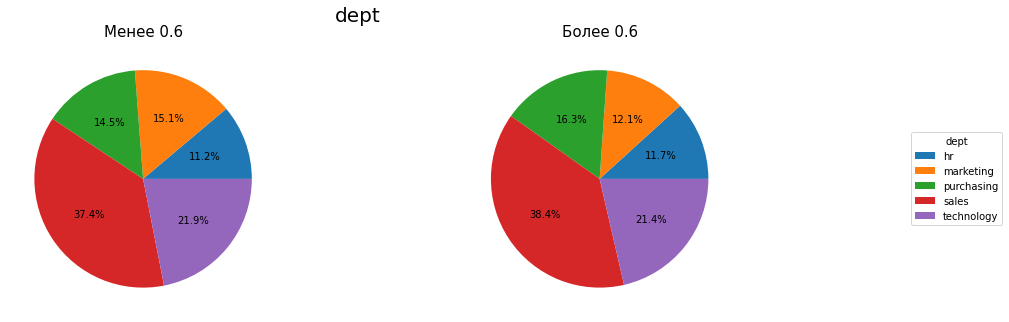

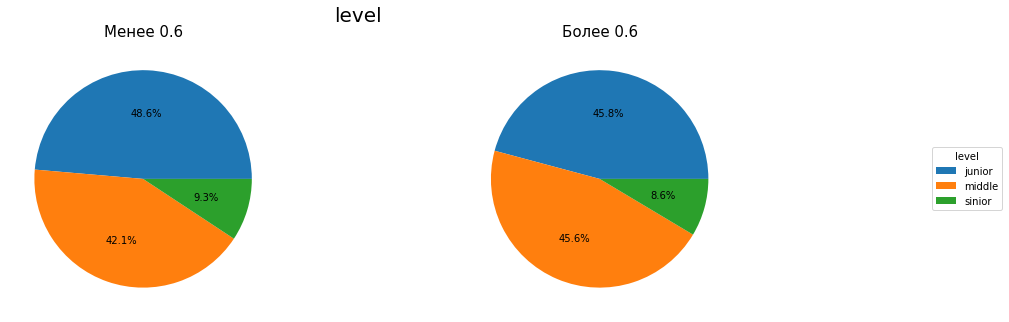

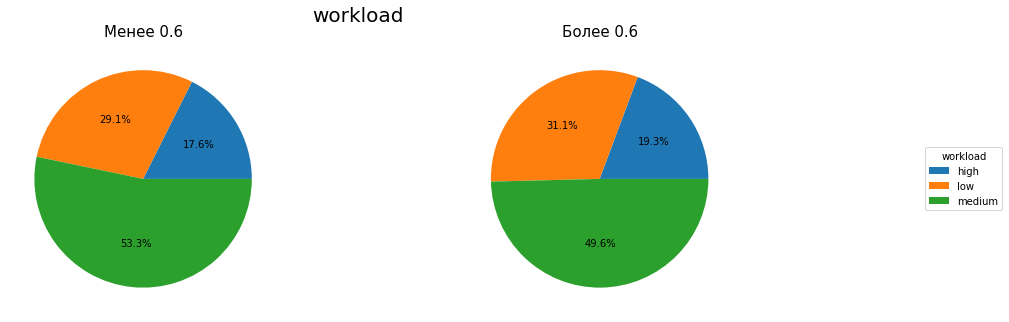

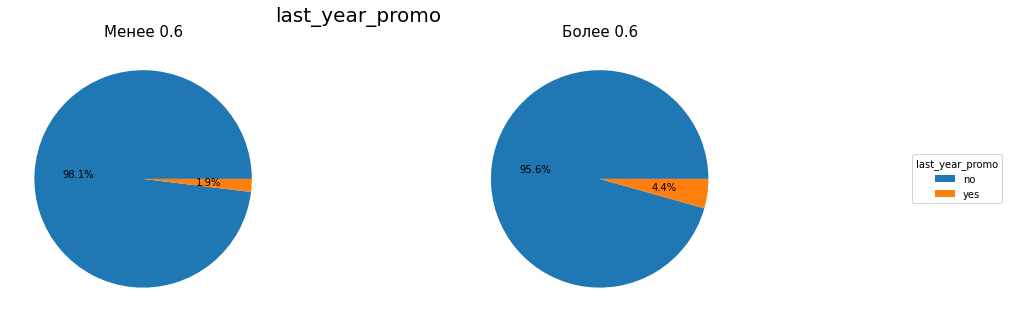

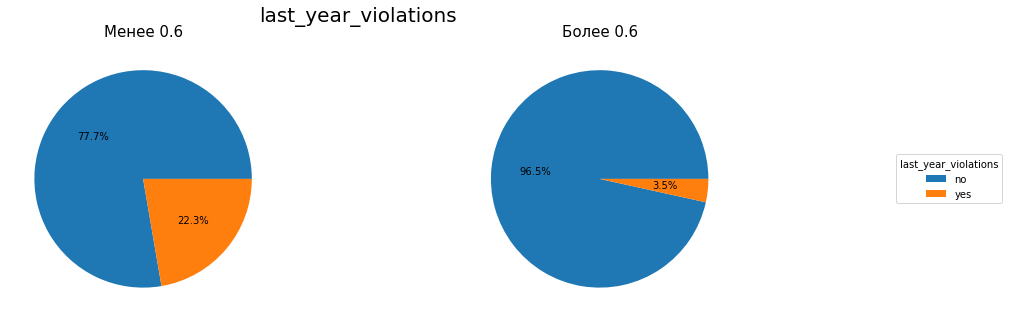

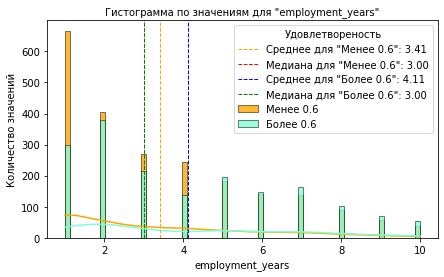

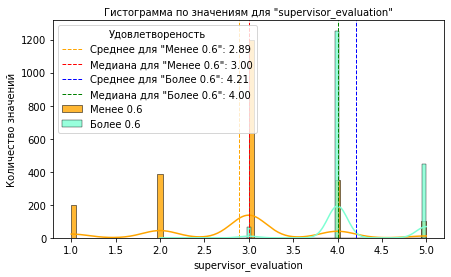

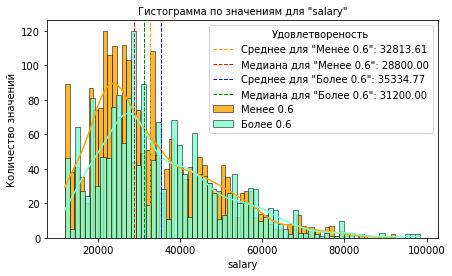

In [36]:
min_max_rate(train_df_rate_min,train_df_rate_max)

Наблюдаются интересные моменты при сопоставлении данных в группе сотрудников с удовлетворенностью менее 0,6 и более 0,6:

- по признаку ‘dept’ в обеих группах сопоставимое распределение по отделам. Лидирует sales.
- по признаку ‘level’ показатели распределения относительно сопоставимы. Лидирует показатель 'middle'.
- по признаку ‘workload’ показатели распределения относительно сопоставимы. Лидирует показатель 'medium'.
- вполне логично, что в группе удовлетворенных работой большее количество повышений за последний год.
- в группе неудовлетворенных работой большее количество нарушений трудового договора. Непонятно, является ли это изначально безответственным отношением сотрудника к работе или уже последствием неудовлетворенности.
- по длительности пребывания сотрудников в компании медианные данные сопоставимы.
- у неудовлетворенных работой и среднее, и медианное значение оценки работы значительно меньше, чем в группе удовлетворенных работой. Опять же непонятно, является ли это изначально безответственным отношением сотрудника к работе или уже последствием неудовлетворенности.
- по показатели зарплат группа неудовлетворенных несколько уступает группе удовлетворенных работой.

**<div style="border:solid green 2px; padding: 20px">
Вывод: На 2 шаге были изучено распределение данных в признаках. Выбросы не обнаружены. Необходимо выявить сотрудников, которые по мнению руководства изначально менее ответственно подходят к работе, а также тех, чье отношение к работе было изменено в процессе работы.**

## Шаг. Корреляционный анализ для задачи №1

### Корреляционный анализ для тестовых данных

Ниже представлена таблица коэффициентов корреляции (шкала Чеддока):

| Значение       | Интерпретация  |
|:--------------:|:--------------:|
| от 0 до 0,3    | очень слабая   |
| от 0,3 до 0,5  | слабая         |
| от 0, 5 до 0,7 | средняя        |
| от 0,7 до 0,9 | высокая        |
| от 0,9 до 1    | очень высокая  |

Используем библиотеку phik для подсчёта корреляции между признаками разных типов данных.

In [37]:
# создаём список с наименованиями количественных признаков
interval_cols = test_df_rate.select_dtypes(include=['int64','float64']).columns.tolist()
    
def corr(data,title):
    # считаем корреляции
    phik_overview = phik_matrix(data.drop('id', axis=1), interval_cols=interval_cols)
    
    plot_correlation_matrix(
        phik_overview.values,
        x_labels=phik_overview.columns,
        y_labels=phik_overview.index,
        vmin=0, vmax=1, color_map='Greens',
        title=title,
        fontsize_factor=1.5,
        figsize=(20, 15)
    ) 

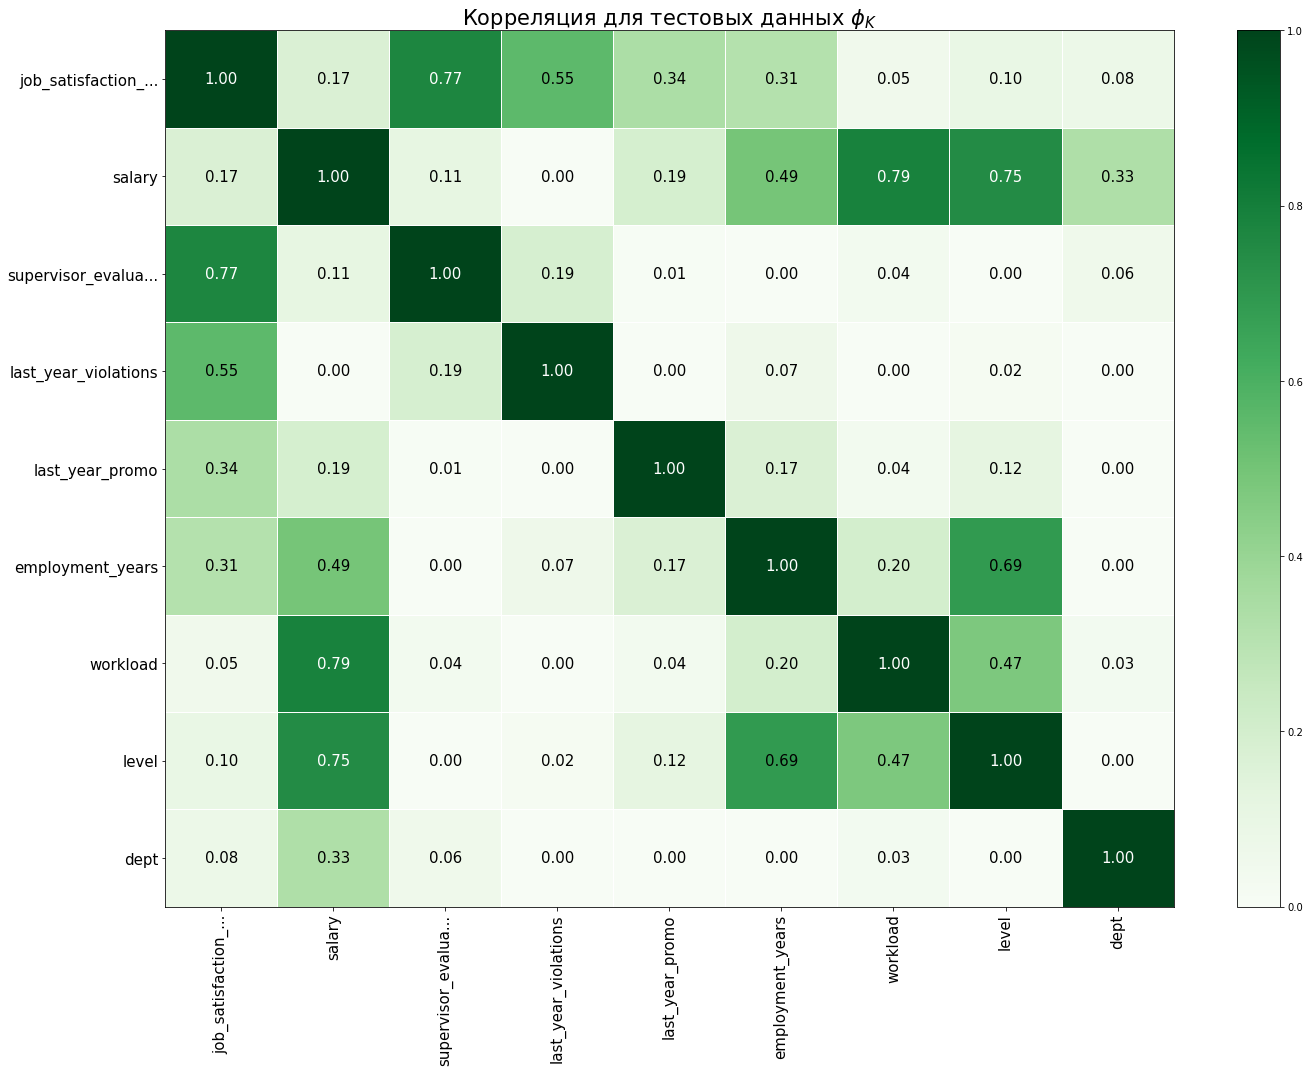

In [38]:
corr(test_df_rate,r'Корреляция для тестовых данных $\phi_K$')

Наблюдается средняя корреляция между целевым признаком и нарушениями трудового договора. Наблюдается высокая корреляция между целевым признаком и оценкой качества работы сотрудника. Мультиколлинеарности не наблюдается.

Рассмотрим данные в зависимости от степени удовлетворенности.

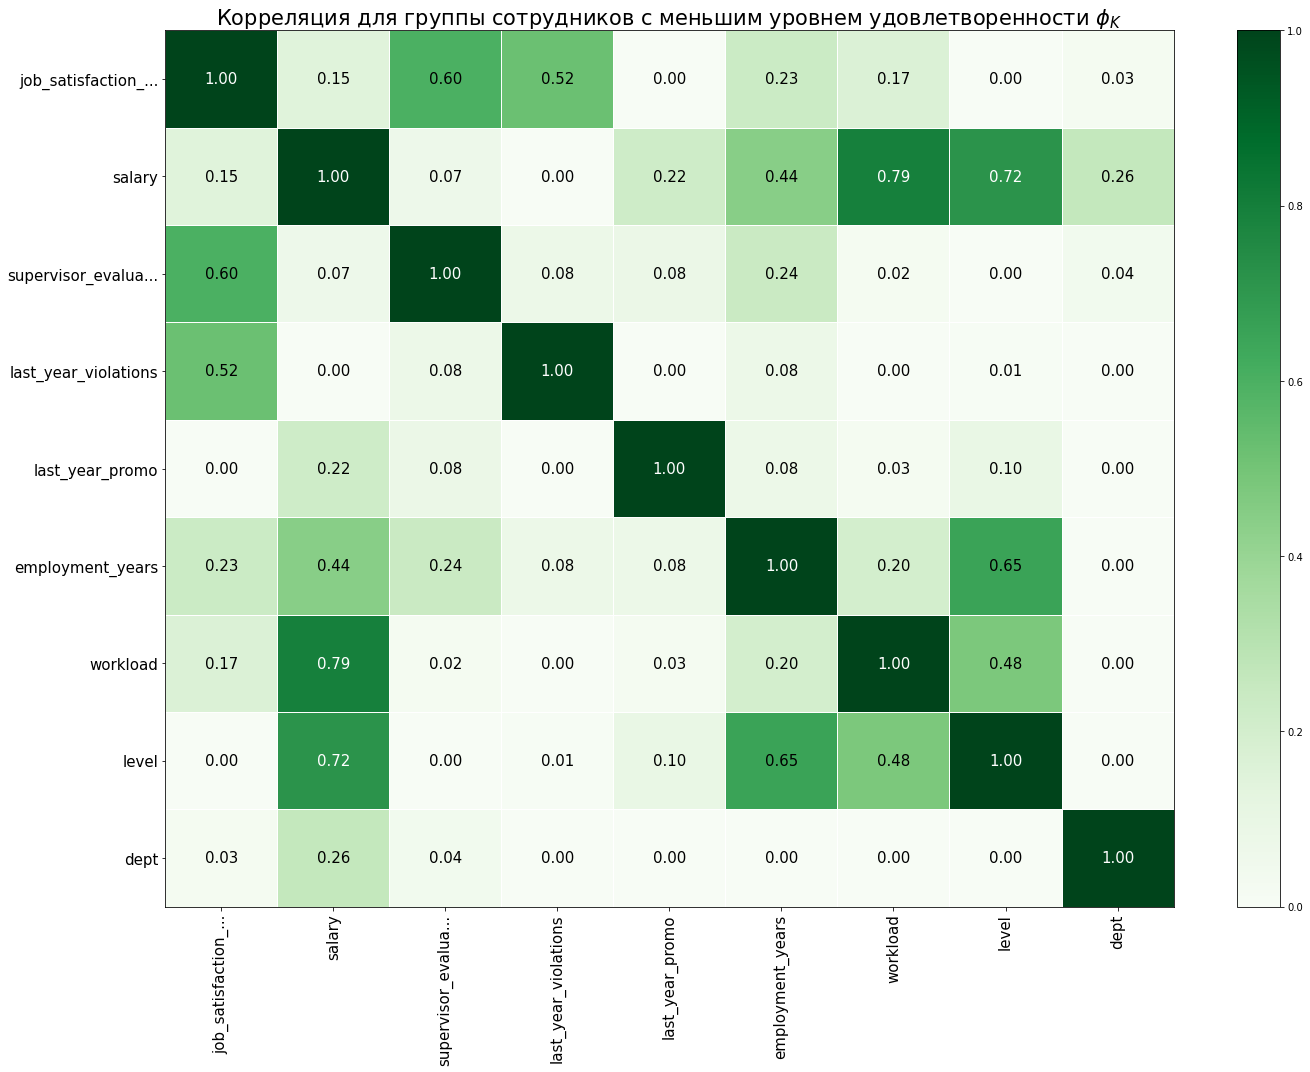

In [39]:
corr(test_df_rate_min,\
r'Корреляция для группы сотрудников с меньшим уровнем удовлетворенности $\phi_K$')

Наблюдается средняя корреляция между целевым признаком, оценкой работы и нарушениями трудового договора. Мультиколлинеарности нет.

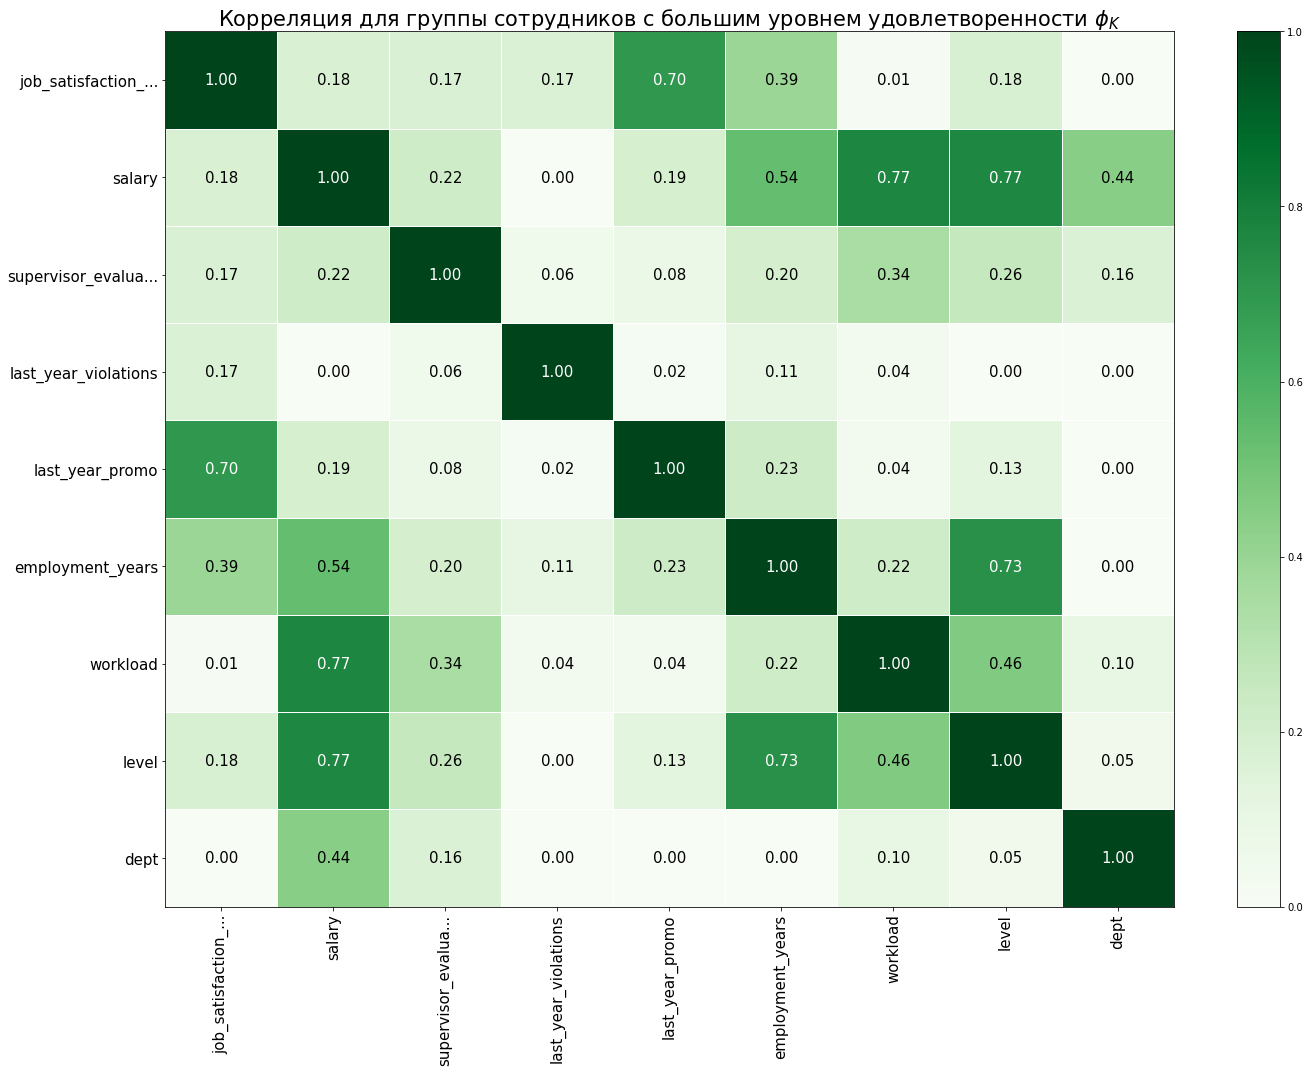

In [40]:
corr(test_df_rate_max,\
r'Корреляция для группы сотрудников с большим уровнем удовлетворенности $\phi_K$')

Картина изменилась. Наблюдается высокая корреляция между целевым признаком и повышениями в последний год. Мультиколлинеарности нет.

Построим диаграммы рассеяния scatterplot для признака 'job_satisfaction_rate' и всех количественных признаков с учётом значения категориальных признаков.

In [41]:
list = ['employment_years','supervisor_evaluation','salary']

def diag_chart(data, parametr): 
    fig,axes = plt.subplots(2, 2, figsize=(9, 9))
    
     # Преобразование 2D массива подграфиков в 1D для удобного индексирования
    axes = axes.ravel()
    
    if parametr == 'dept':            
        fig.suptitle('Категориальные признак "dept"')
    elif parametr == 'level':             
        fig.suptitle('Категориальные признак "level"')
    elif parametr == 'workload':            
        fig.suptitle('Категориальные признак "workload"')
    elif parametr=='last_year_promo':
        fig.suptitle('Категориальные признак "last_year_promo"')
    elif parametr=='last_year_violations':
        fig.suptitle('Категориальные признак "last_year_violations"')
    for i, column in enumerate(list):
        sns.scatterplot(data=data, x=column, y='job_satisfaction_rate', hue=parametr, ax = axes[i])
    plt.show()           

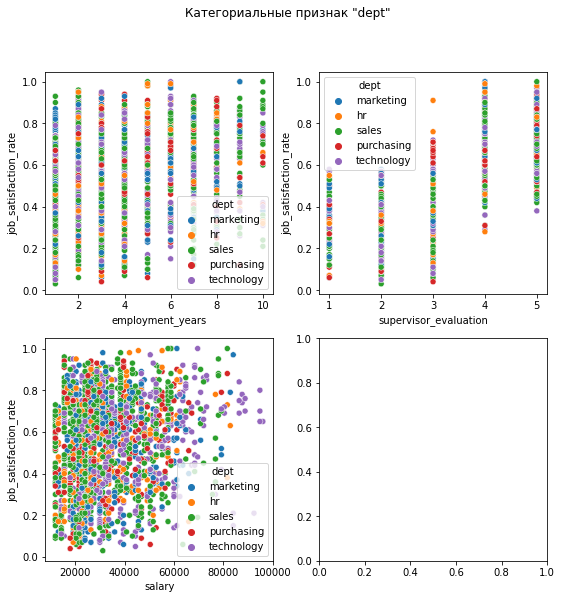

In [42]:
diag_chart(test_df_rate, 'dept')

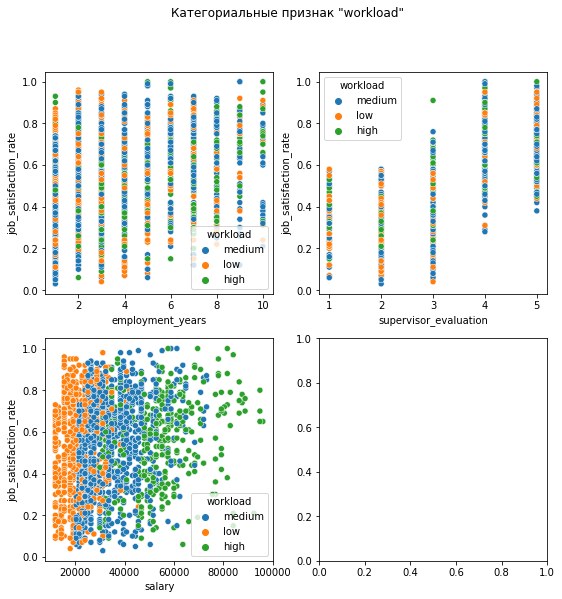

In [43]:
diag_chart(test_df_rate, 'workload')

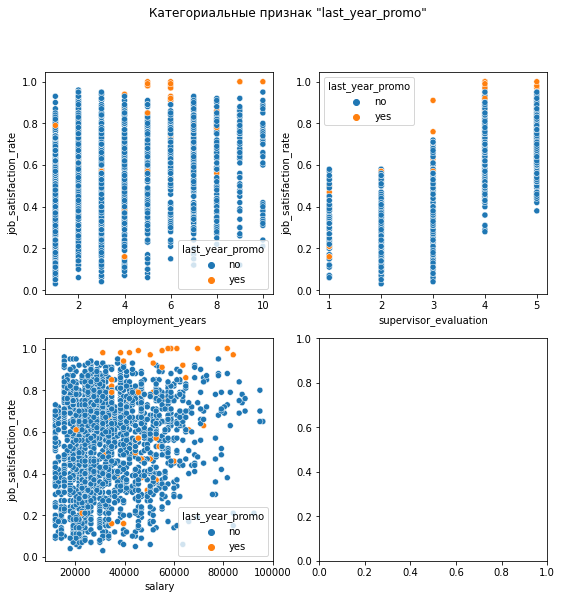

In [44]:
diag_chart(test_df_rate, 'last_year_promo')

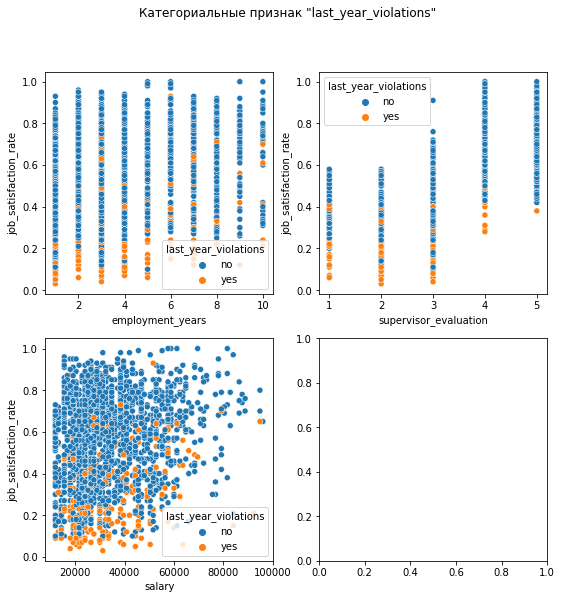

In [45]:
diag_chart(test_df_rate, 'last_year_violations')

По результатам построения графиков наблюдается только зависимость между уровнем специалиста и зарплатой.

### Корреляционный анализ для тренировочных данных

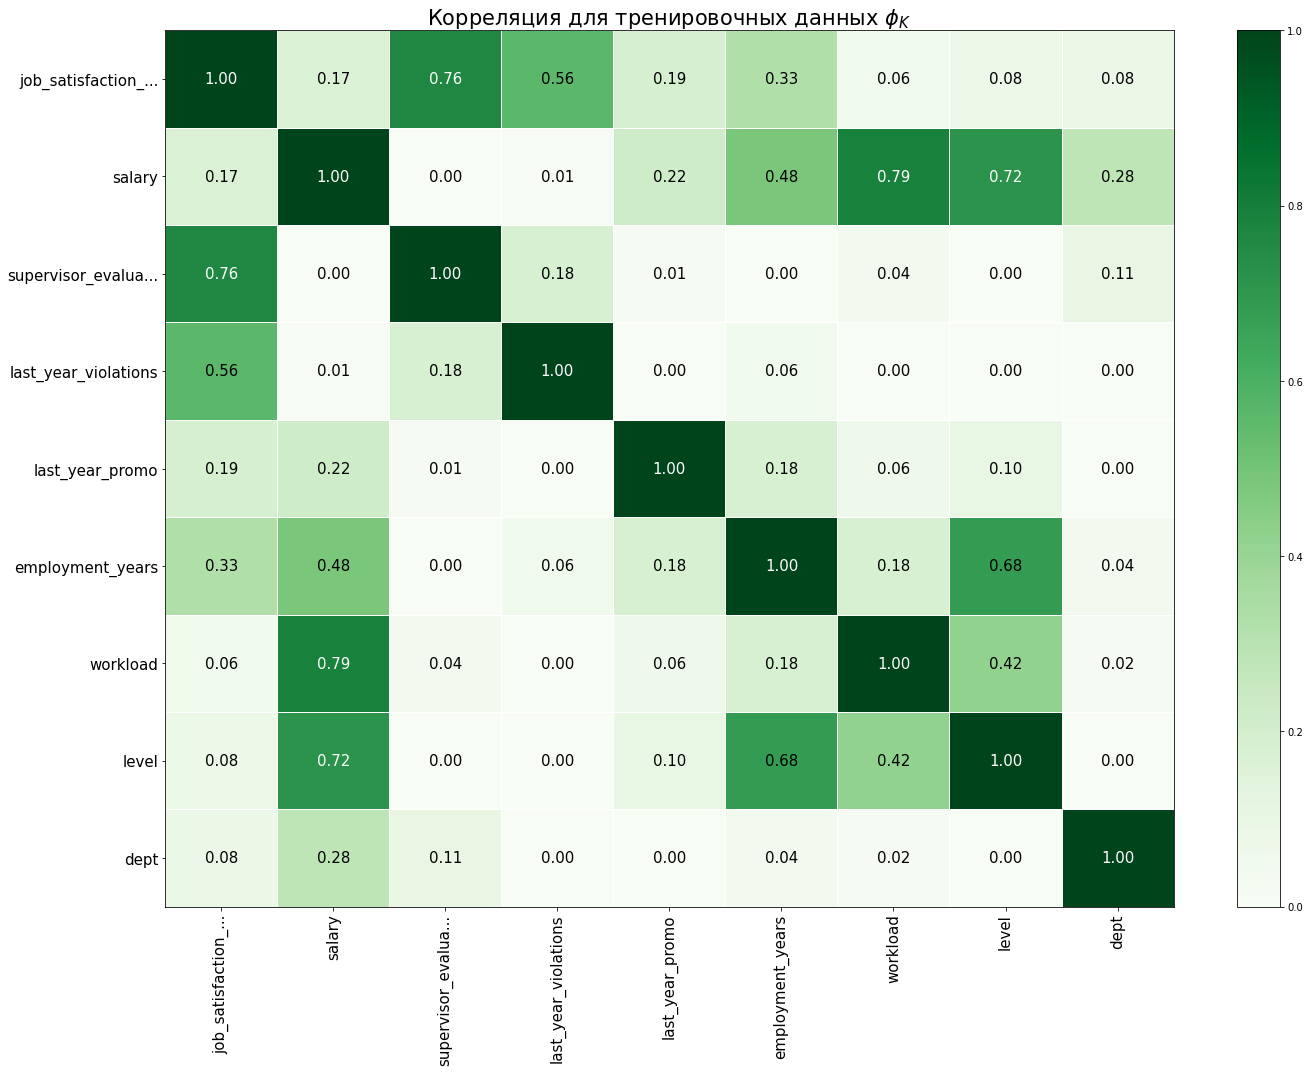

In [46]:
corr(train_job_satisfaction_rate,\
     r'Корреляция для тренировочных данных $\phi_K$')

Наблюдается средняя корреляция между целевым признаком и нарушениями трудового договора. Наблюдается высокая корреляция между целевым признаком и оценкой качества работы сотрудника. Мультиколлинеарности не наблюдается.

Рассмотрим данные в зависимости от степени удовлетворенности.

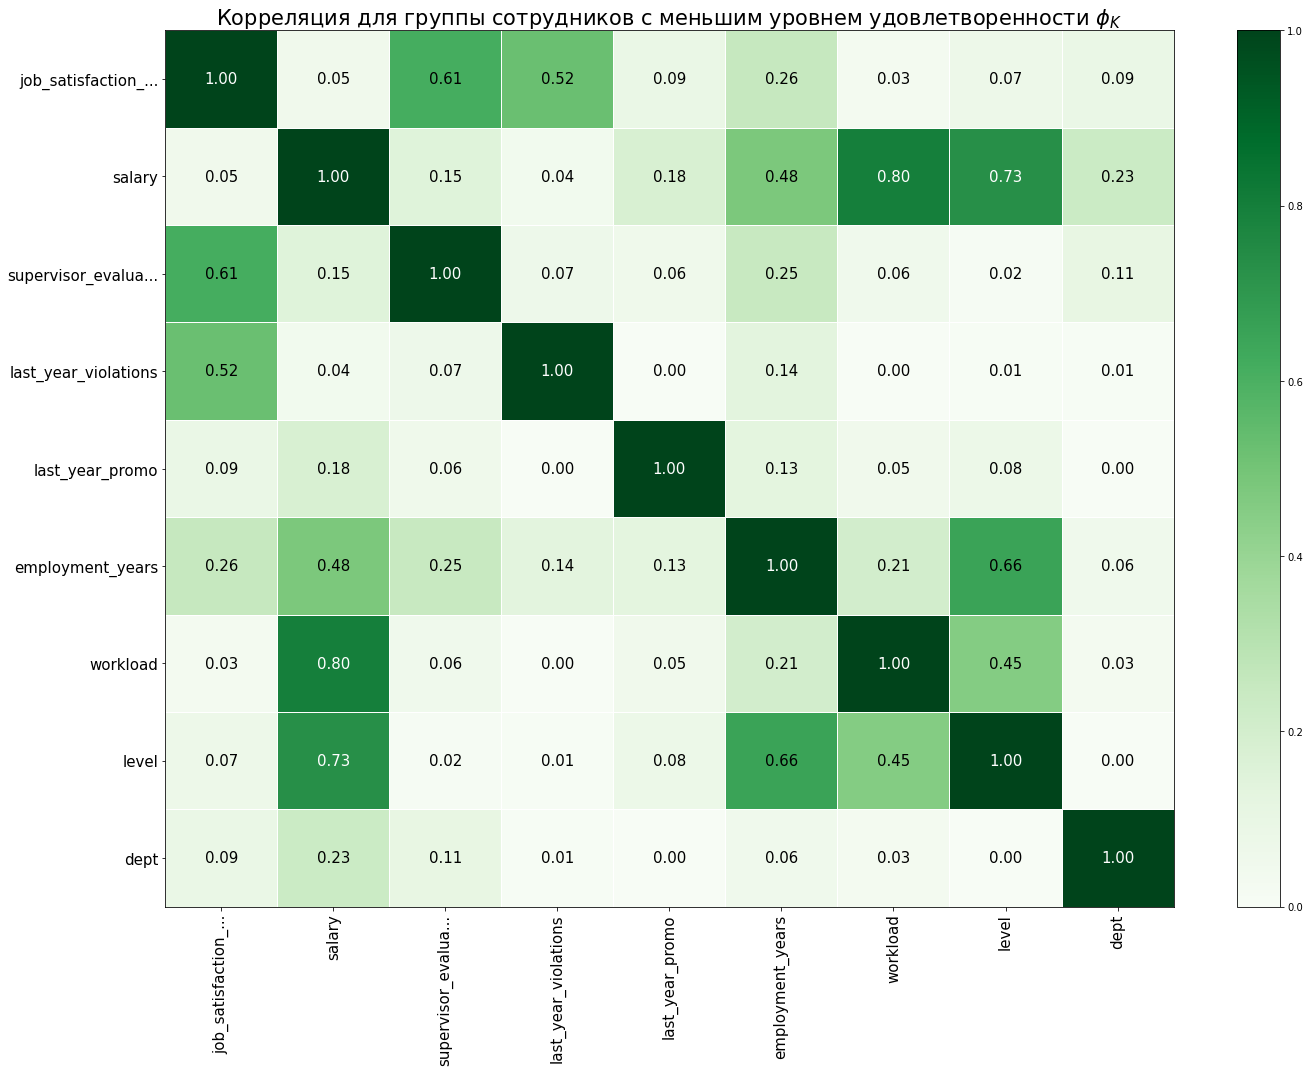

In [47]:
corr(train_df_rate_min,\
r'Корреляция для группы сотрудников с меньшим уровнем удовлетворенности $\phi_K$')

Наблюдается средняя корреляция между целевым признаком, оценкой работы и нарушениями трудового договора. Мультиколлинеарности нет.

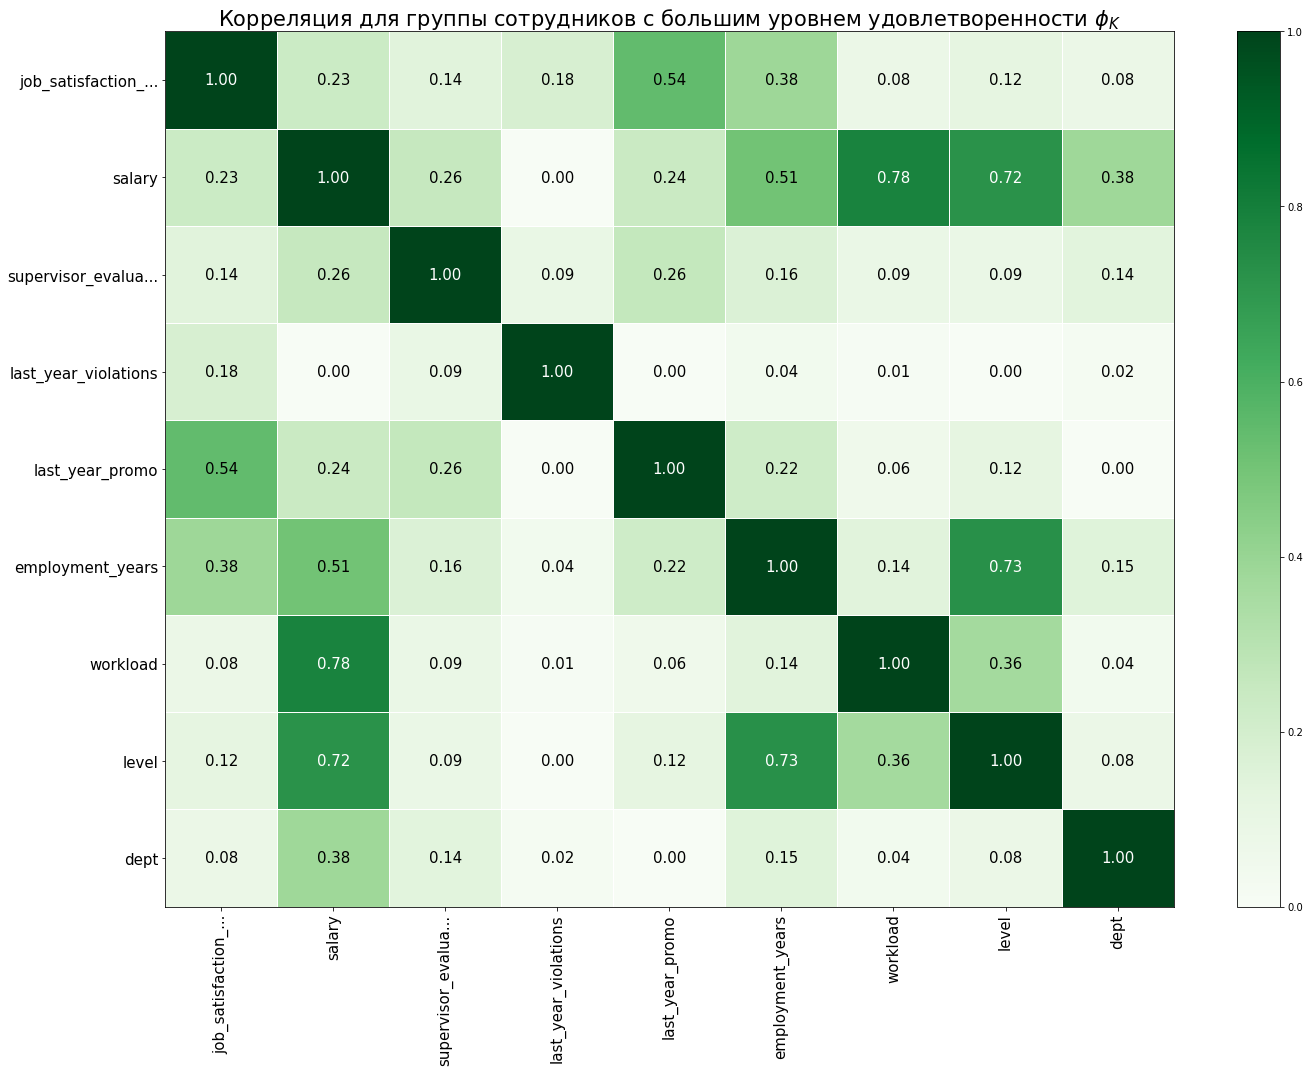

In [48]:
corr(train_df_rate_max,\
    r'Корреляция для группы сотрудников с большим уровнем удовлетворенности $\phi_K$')

Картина опять же изменилась. Наблюдается средняя корреляция между целевым признаком и повышениями в последний год. Мультиколлинеарности нет.

Построим диаграммы рассеяния scatterplot для признака 'job_satisfaction_rate' и всех количественных признаков с учётом значения категориальных признаков.

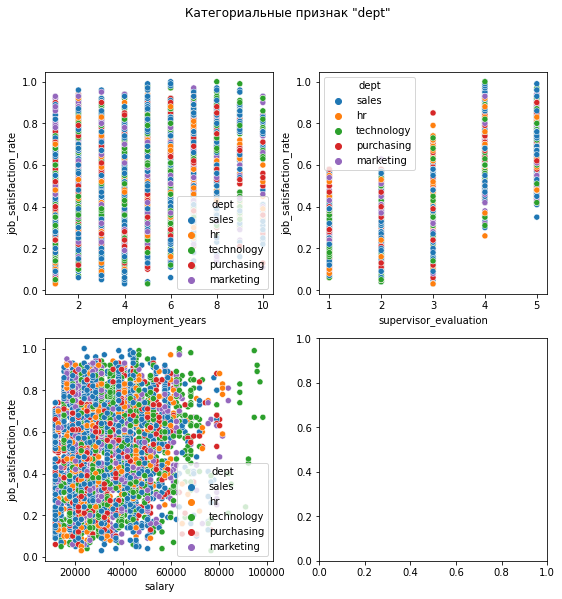

In [49]:
diag_chart(train_job_satisfaction_rate, 'dept')

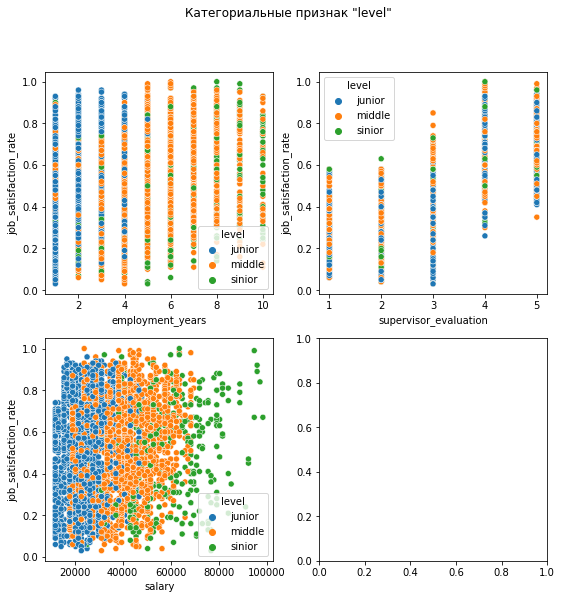

In [50]:
diag_chart(train_job_satisfaction_rate, 'level')

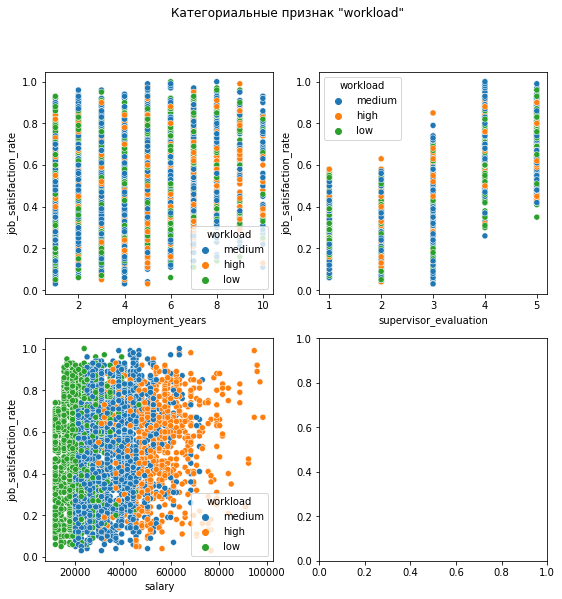

In [51]:
diag_chart(train_job_satisfaction_rate, 'workload')

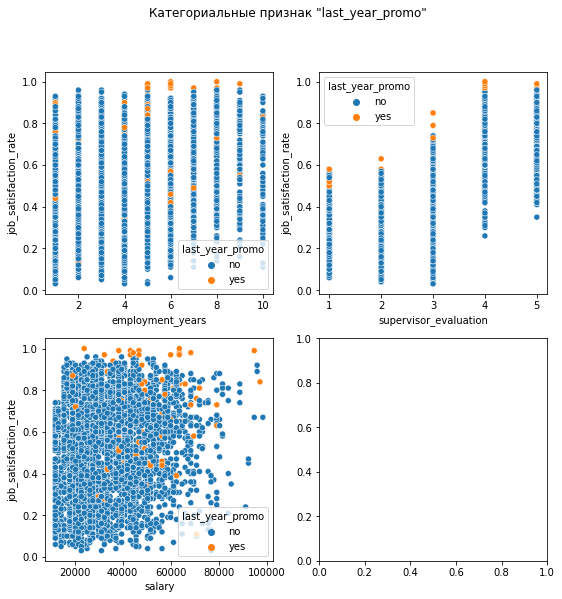

In [52]:
diag_chart(train_job_satisfaction_rate, 'last_year_promo')

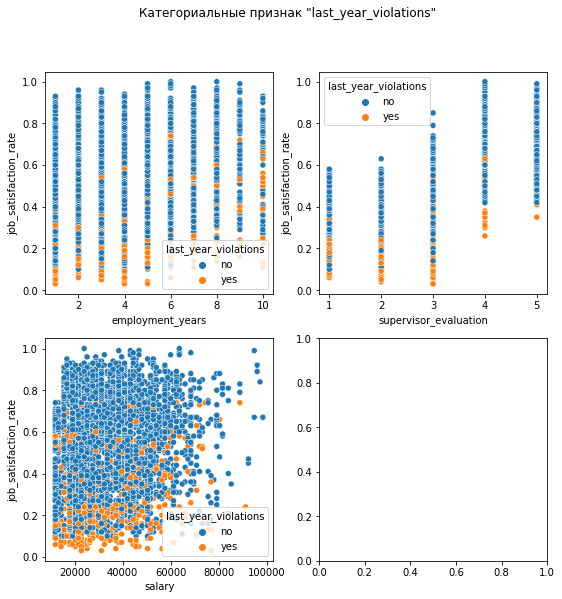

In [53]:
diag_chart(train_job_satisfaction_rate, 'last_year_violations')

По результатам построения графиков наблюдается только зависимость между уровнем специалиста и зарплатой.

**<div style="border:solid green 2px; padding: 20px">
Вывод: На 3 шаге был проведен корреляционный анализ. В зависимости от степени удовлетворенности наблюдается корреляция целевого признака и оценкой работы сотрудника, повышением и нарушениями трудового договора. Мультиколлинеарности не наблюдается.**

## Шаг. Подготовка данных для задачи №1

Удалим признак 'id' из 'train_job_satisfaction_rate'.

In [54]:
train_no_id = train_job_satisfaction_rate.drop('id',axis=1)

In [55]:
train_no_id.shape

(4000, 9)

In [56]:
display(train_no_id.head())

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,sales,junior,medium,2,no,no,1,24000,0.58
1,hr,junior,high,2,no,no,5,38400,0.76
2,sales,junior,low,1,no,no,2,12000,0.11
3,technology,junior,low,4,no,no,2,18000,0.37
4,hr,junior,medium,1,no,no,3,22800,0.20


Проверим датасет на количество явных дубликатов.

In [57]:
print('Количество полных дубликатов ', train_no_id.duplicated().sum())

Количество полных дубликатов  245


Удалим данные дубликаты, т.к. они будут искажать модель.

In [58]:
train_no_id = train_no_id.drop_duplicates().reset_index(drop=True)
print('Количество полных дубликатов:',train_no_id.duplicated().sum())

Количество полных дубликатов: 0


In [59]:
# создаём списки с названиями признаков
ohe_columns = ['dept', 'last_year_promo','last_year_violations']
ord_columns = ['level','workload']
num_columns = train_no_id.drop('job_satisfaction_rate',axis=1).\
select_dtypes(include=['int64','float64']).columns.tolist()

In [60]:
# разбивка данных
X_train = train_no_id.drop('job_satisfaction_rate',axis=1)
y_train = train_no_id['job_satisfaction_rate']

X_test = test_df_rate.drop(['id','job_satisfaction_rate'],axis=1)
y_test = test_df_rate['job_satisfaction_rate']

In [61]:
# создаём пайплайн для подготовки признаков из списка ohe_columns:
#заполнение пропусков и OHE-кодирование
# SimpleImputer + OHE
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='error', sparse_output=False))
    ]
    )

# создаём пайплайн для подготовки признаков из списка ord_columns:
#заполнение пропусков и Ordinal-кодирование
# SimpleImputer + OE
ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(
                categories=[
                    ['junior', 'middle', 'sinior'],
                    ['low', 'medium','high']
                ], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

In [62]:
# создаём итоговый пайплайн: подготовка данных
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

**<div style="border:solid green 2px; padding: 20px">
Вывод: На 4 шаге были подготовлены данные в пайплайне. Для столбцов 'dept', 'last_year_promo','last_year_violations' был использован OneHotEncoder, для столбцов 'level','workload' - OrdinalEncoder.**

## Шаг. Обучение моделей для задачи №1

В первую очередь была использована линейная модель. Также были использованы DecisionTreeRegressor и KNeighborsRegressor. Дерево решений (DecisionTreeClassifier) применяется для дискретных целевых переменных, дерево регрессии (DecisionTreeRegressor), когда целевая переменная непрерывна (как в нашем случае). Аналогичная ситуация с моделями KNeighborsClassifier и KNeighborsRegressor.

In [63]:
param_grid = [
    # словарь для модели DecisionTreeRegressor()
    {
        'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'models__criterion': ['squared_error','friedman_mse','absolute_error','poisson'],
        'models__max_depth': range(2, 10),
        'models__max_features': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']  
    },
    
    # словарь для модели KNeighborsRegressor() 
    {
        'models': [KNeighborsRegressor()],
        'models__n_neighbors': range(2, 20),
        'models__metric': ['euclidean', 'manhattan'],
        'models__weights': ['uniform', 'distance'],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },
    
    # словарь для модели LinearRegression()
    {
        'models' : [LinearRegression(n_jobs=-1)],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough'] 
    }
]

**Cимметричная средняя абсолютная процентная ошибка (Symmetric Mean Absolute Percentage Error)** — это мера точности, основанная на процентных (или относительных) ошибках. Обычно определяется следующим образом:

<img decoding="async" src="https://vedexcel.com/wp-content/uploads/2020/12/SMAPE_Python.png" alt="SMAPE Formula Python" class="wp-image-134" width="332" height="90" title="SMAPE Python Formula" srcset="https://vedexcel.com/wp-content/uploads/2020/12/SMAPE_Python.png 443w, https://vedexcel.com/wp-content/uploads/2020/12/SMAPE_Python-300x81.png 300w" sizes="(max-width: 332px) 100vw, 332px">

Т.е. абсолютная разность между наблюдаемым и предсказанным значениями делится на полусумму их модулей.

In [64]:
def smape_score(y_true, y_pred):
    n = len(y_true)
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    summ = np.sum(numerator / denominator)
    smape_value = summ * (100 / n)
    return smape_value

In [65]:
smape_scorer = make_scorer(smape_score, greater_is_better=False)

В качестве инструмента автоматизированного поиска был выбран **GridSearchCV**. Он осуществляет перебор по сетке, все указанные значения гиперпараметров будут перебираться. Его лучше использовать при переборов небольших диапазонов значений.

In [66]:
grid_search = GridSearchCV(
    pipe_final, 
    param_grid=param_grid, 
    cv=5,
    scoring=smape_scorer,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ohe',
                                                                         Pipeline(steps=[('simpleImputer_ohe',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('ohe',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        sparse_output=False))]),
                                                                         ['dept',
                                                                          'last_year_promo',
                                                                          'last_year_violations']),
                                                                        ('ord',
                                                                         Pipeline(steps=[('simpleImputer_b...
                          'models__metric': ['euclidean', 'manhattan'],
                          'models__n_neighbors': range(2, 20),
                          'models__weights': ['uniform', 'distance'],
                          'preprocessor__num': [StandardScaler(),
                                                MinMaxScaler(),
                                                'passthrough']},
                         {'models': [LinearRegression(n_jobs=-1)],
                          'preprocessor__num': [StandardScaler(),
                                                MinMaxScaler(),
                                                'passthrough']}],
             scoring=make_scorer(smape_score, greater_is_better=False, response_method='predict'))

In [67]:
print('Лучшая модель и её параметры:\n\n', grid_search.best_estimator_)
print('Параметры лучшей модели:', grid_search.best_params_)
print('Метрика лучшей модели при применении кросс-валидации:', grid_search.best_score_*-1)

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
                                       

In [68]:
y_pred = grid_search.best_estimator_.predict(X_test)
print(f'Метрика SMAPE на тестовой выборке: {smape_score(y_test, y_pred)}')

Метрика SMAPE на тестовой выборке: 13.947735521278588


Критерий успеха: SMAPE ≤ 15 на тестовой выборке.

При создании модели машинного обучения для какого-либо проекта разумно сначала создать baseline модель. Она представляет собой простейшую (dummy) модель, которая всегда предсказывает наиболее часто встречающийся класс. Так мы получим контрольные данные для сравнительной оценки построенной нами более сложной модели. К тому же мы сможете быть уверены в качестве ее работы, например, в том, что она выдает не просто набор случайно подобранных данных.

В библиотеке scikit-learn есть DummyClassifier() для задач классификации и DummyRegressor() для работы с регрессией.

In [69]:
# создадим и обучим DummyRegressor на тренировочных данных
# выполним предсказание на тестовой выборке
dummy_model = DummyRegressor()

dummy_model.fit(X_train, y_train)
dummy_model_preds = dummy_model.predict(X_test)

print(f'Метрика SMAPE на тестовой выборке: {smape_score(y_test, dummy_model_preds)}')

Метрика SMAPE на тестовой выборке: 38.26225790202238


**Значение SMAPE на выбранной пайплайном модели значительно превосходит значение, полученное на модели DummyRegressor, что говорит о ее адекватности.**

Проверим остатки модели.

In [70]:
def prepare_data(X_train,X_test,scaler):
    global X_train_for_model,X_test_for_model
    
    imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
    
    # считаем моду на тренировочной выборке
    imputer.fit(X_train)
    
    # заполняем пропуск в тестовых данных на моду
    X_train[imputer.feature_names_in_] = imputer.transform(X_train)
    X_test[imputer.feature_names_in_] = imputer.transform(X_test)

    
    # подготовка признаков
    encoder = OneHotEncoder(drop='first', handle_unknown='error', sparse_output=False)
    X_train_ohe = encoder.fit_transform(X_train[ohe_columns])
    X_test_ohe = encoder.transform(X_test[ohe_columns])

    encoder_col_names = encoder.get_feature_names_out()
    
    X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
    X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

    ord_encoder = OrdinalEncoder(categories=[
                    ['junior', 'middle', 'sinior'],
                    ['low', 'medium','high']
                ],
                handle_unknown='use_encoded_value', unknown_value=np.nan)
        
    X_train_ord = ord_encoder.fit_transform(X_train[ord_columns])
    X_test_ord = ord_encoder.transform(X_test[ord_columns])

    X_train_ord = pd.DataFrame(X_train_ord, columns=ord_columns)
    X_test_ord = pd.DataFrame(X_test_ord, columns=ord_columns)
    
    if scaler == 'passthrough':
        X_train_scaled = X_train[num_columns]
        X_test_scaled = X_test[num_columns] 
    else:
        scaler = scaler
    
        X_train_scaled = scaler.fit_transform(X_train[num_columns])
        X_test_scaled = scaler.transform(X_test[num_columns])    
    
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_columns)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_columns)    

    X_train_for_model = pd.concat([X_train_ohe, X_train_ord, X_train_scaled], axis=1)
    X_test_for_model = pd.concat([X_test_ohe, X_test_ord, X_test_scaled], axis=1)

In [71]:
prepare_data(X_train,X_test,StandardScaler())

R2 = 0.8790084465476068


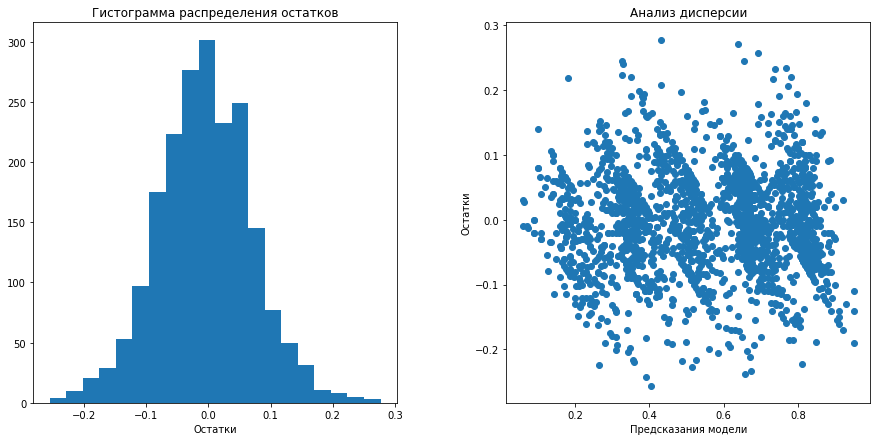

In [72]:
#создание объекта для работы с моделью
model = KNeighborsRegressor(metric='manhattan',n_neighbors=9,weights='distance')

#обучение модели на тренировочных данных
model = model.fit(X_train_for_model, y_train)

# получение предсказания модели на тестовых данных 
# сохранение результата в переменную predictions
predictions = model.predict(X_test_for_model)

# расчет значения R2 для линейной регрессии
r2 = r2_score(y_test, predictions)

# вывод полученного значения R2
print("R2 =", r2)

# проведение анализа остатков
residuals = y_test - predictions

# построение графиков по количественным признакам — гистограмму частотности 
# распределения и диаграмму рассеяния
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,7))
plt.subplots_adjust(wspace=0.3, hspace=0.3)
axes[0].hist(residuals, bins = 20)
axes[0].set_title('Гистограмма распределения остатков')
axes[0].set_xlabel('Остатки')

axes[1].scatter(predictions,residuals)
axes[1].set_xlabel('Предсказания модели')
axes[1].set_ylabel('Остатки')
axes[1].set_title('Анализ дисперсии')
plt.show()

Модель показывает хороший результат. R2 высокая, гистограмма не имеет сдвигов, а чередование маленьких и больших дисперсий остатков не выражено.

**<div style="border:solid green 2px; padding: 20px">
Вывод: На 5 шаге были обучены 3 модели: LinearRegression, DecisionTreeRegressor, KNeighborsRegressor. Критерий успеха для моделей был заложен SMAPE ≤ 15 на тестовой выборке.
Для лучшей модели данный параметр составил 13.947735521278588 ({'models': KNeighborsRegressor(), 'models__metric': 'manhattan', 'models__n_neighbors': 9, 'models__weights': 'distance', 'preprocessor__num': StandardScaler()})**

## Шаг. Анализ важности признаков для задачи №1

### Анализ важности признаков самой моделью

У объекта «KNeighborsRegressor» отсутствует атрибут «coef_». Отсутсвует возможность оценить важность признаков.

### Подбор важных признаков с применение SelectKBest()

In [73]:
#создадим списки показателей
k = [] #количество признаков
smape = [] #показатель smape
mae = [] #показатель mae
rmse = [] #показатель rmse
mse = [] #показатель mse
r2 = [] #показатель r2_score
priz_names = [] #перечень признаков

#Обучаем модель
model = KNeighborsRegressor(metric='manhattan',n_neighbors=9,weights='distance')

for i in range(1, 12):
    #селектор
    selector = SelectKBest(f_classif, k=i)

    #применяем SelectKBest к набору тренировочных данных
    X_train_select = selector.fit_transform(X_train_for_model, y_train)
    
    #применяем SelectKBest к набору тестовых данных
    X_test_select = selector.transform(X_test_for_model)
    
    #обучаем модель на отобранных признаках
    model.fit(X_train_select, y_train)
    
    #применяем модель к тестовым данным
    y_pred_select = model.predict(X_test_select)
    
    index = selector.get_support(indices=True)
    
    k.append(i)
    
    #выводим значения smape
    smape.append(round(smape_score(y_test, y_pred_select), 3))
    
    #выводим mse
    mse.append(round(mean_squared_error(y_pred_select,y_test), 3))
    
    #выводим rmse
    rmse.append(round(mean_squared_error(y_pred_select,y_test)**0.5, 3))
              
    #выводим mae
    mae.append(round(mean_absolute_error(y_pred_select,y_test), 3))
    
    #выводим r2_score
    r2.append(round(r2_score(y_test, y_pred_select),3))
    
    #извлекаем названия выбранных признаков из исходного датасета
    feature_names = X_train_for_model.columns[index].tolist()
    
    priz_names.append(feature_names)

#создаем отдельный датасет для метрик
metric = pd.DataFrame({'k': k,
                       'SMAPE': smape,
                       'MSE': mse,
                       'RMSE': rmse,
                       'MAE': mae,
                       'R2-score':r2,
                       'Признаки': priz_names
                       
                       }
                     )
              
display(metric)


,k,SMAPE,MSE,RMSE,MAE,R2-score,Признаки
0,1,24.729,0.019,0.137,0.109,0.613,[supervisor_evaluation]
1,2,22.590,0.016,0.126,0.101,0.672,"[last_year_violations_yes, supervisor_evaluation]"
2,3,22.636,0.016,0.125,0.101,0.676,"[last_year_promo_yes, last_year_violations_yes..."
3,4,20.538,0.013,0.112,0.090,0.741,"[last_year_promo_yes, last_year_violations_yes..."
4,5,19.221,0.012,0.109,0.083,0.756,"[last_year_promo_yes, last_year_violations_yes..."
5,6,18.525,0.011,0.105,0.080,0.774,"[dept_purchasing, last_year_promo_yes, last_ye..."
6,7,17.017,0.009,0.097,0.074,0.805,"[dept_purchasing, dept_technology, last_year_p..."
7,8,15.497,0.007,0.085,0.066,0.850,"[dept_purchasing, dept_technology, last_year_p..."
8,9,14.810,0.007,0.082,0.063,0.862,"[dept_marketing, dept_purchasing, dept_technol..."
9,10,14.291,0.006,0.078,0.061,0.873,"[dept_marketing, dept_purchasing, dept_sales, ..."


Наилучшие метрики получаются именно когда участвуют все 11 признаков.

### Проверка permutation importance

**Permutation importance** подсвечивает качество модели с ещё одной стороны. Он показывает, насколько изменятся метрики, если поочерёдно рандомизировать каждый входной признак модели.

/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsRegressor was fitted without feature names
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has fea

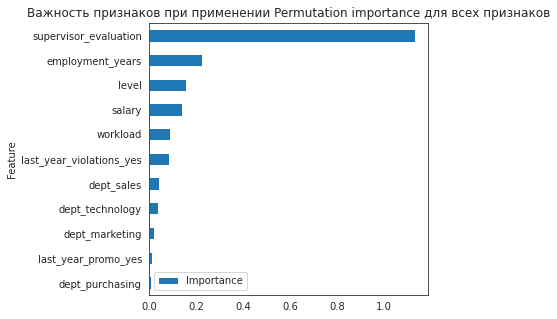

In [74]:
def custom_r2(model, X, y):
    y_pred = model.predict(X)
    score = r2_score(y, y_pred)
    return score

result = permutation_importance(model, X_test_for_model, y_test, scoring=custom_r2)

feature_importance = pd.DataFrame({'Feature': X_test_for_model.columns,\
                                   'Importance': result['importances_mean']})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
sns.set_style('white')
feature_importance.plot(x='Feature', y='Importance', kind='barh',\
                        figsize=(5, 5)).\
set_title("Важность признаков при применении Permutation importance для всех признаков");

При применении Permutation importance в топ-5 признаков попали:
    
- оценка качества работы сотрудника
- длительность работы на компанию
- уровень работника
- зарплата
- загрузка сотрудника

Наименее значимым признаком признана работа в департаменте закупок.

### Анализ SHAP-значений

Однозначную оценку вклада признака в каждый прогноз показывают значения Шепли, их оценивают методом **SHAP (SHapley Additive exPlanations)**. Он вычисляет, как отдельный признак помог присвоить модели итоговое значение целевого.

  0%|          | 0/2000 [00:00<?, ?it/s]

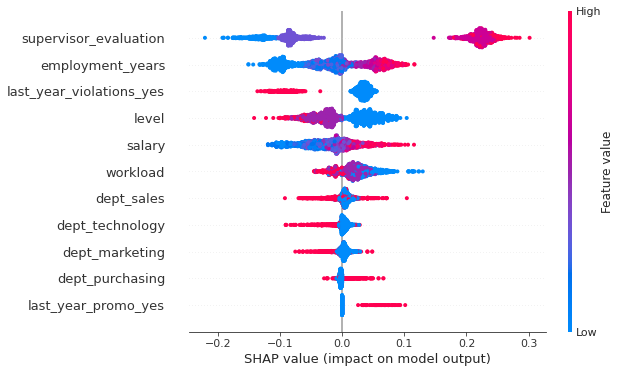

In [75]:
sample = shap.sample(X_train_for_model, nsamples=10, random_state=RANDOM_STATE)

# Инициализируем KernelExplainer с суммарным фоном
explainer = shap.KernelExplainer(model.predict, sample)

# Вычисляем SHAP значения
shap_values = explainer(X_test_for_model)

# Визуализируем SHAP значений с помощью графика beeswarm
shap.plots.beeswarm(shap_values, max_display=16);

- значения слева от центральной вертикальной линии — это negative класс (0), справа — positive (1)
- чем толще линия на графике, тем больше таких точек наблюдения
- чем краснее точки на графике, тем выше значения признака в ней

Проверим еще раз показатель 'level'.

In [76]:
X_train['level'].value_counts()

junior    1703
middle    1695
sinior     357
Name: level, dtype: int64

In [77]:
X_train_for_model['level'].value_counts()

0.0    1703
1.0    1695
2.0     357
Name: level, dtype: int64

In [78]:
X_train['job_satisfaction_rate'] = y_train
X_train.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,sales,junior,medium,2,no,no,1,24000,0.58
1,hr,junior,high,2,no,no,5,38400,0.76
2,sales,junior,low,1,no,no,2,12000,0.11
3,technology,junior,low,4,no,no,2,18000,0.37
4,hr,junior,medium,1,no,no,3,22800,0.20


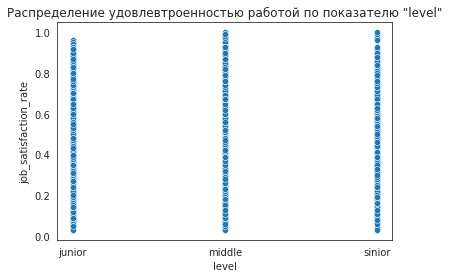

In [79]:
sns.scatterplot(data=X_train, x='level', y='job_satisfaction_rate')
plt.title('Распределение удовлевтроенностью работой по показателю "level"');

In [80]:
table = X_train.pivot_table(index='level', values='job_satisfaction_rate', aggfunc=['mean','median'])
display(table)

,mean,median
,job_satisfaction_rate,job_satisfaction_rate
level,,
junior,0.520910,0.54
middle,0.546985,0.57
sinior,0.519580,0.54


По результатам анализа SHAP-значений в топ-5 признаков попали:

- оценка работы сотрудника (чем выше оценка, тем выше уровень удовлетворенности работой)
- продолжительность работы в компании (чем больше лет, тем выше уровень удовлетворенности работой)
- количество нарушений трудового договора (чем меньше нарущений, тем выше уровень удовлетворенности работой)
- уровень сотрудника (у сотрудников с большим уровнем, ниже уровень удовлетворенности работой)
- зарплата (чем выше, тем выше уровень удовлетворенности работой)

Наименее значимым признаком признано наличие/отсутствие повышения.

<div style="border:solid green 2px; padding: 20px">
Вывод: На шаге 6 была проанализирована важность признаков. В топ важных признаков вошли:

- оценка работы сотрудника
- продолжительность работы на компанию
- уровень сотрудника
- зарплата
    
Наименее значимыми признаками признаны наличие повышения и работа в департаменте закупок. 

## Шаг. Оформление выводов для задачи №1

<div style="border:solid green 2px; padding: 20px">
Вывод: По итогам задачи №1 были выполнены следующие этапы:
    
- загружены файлы с данными;
- проведена обработка данных, пропуски не заполнялись (были заполнены в пайплайне);
- проведен исследовательский анализ данных;
- проведен корреляционный анализ;
- были подготовлены признаки в пайплайне;
- были обучены 3 модели: LinearRegression, DecisionTreeRegressor, KNeighborsRegressor. Критерий успеха для моделей был заложен SMAPE ≤ 15 на тестовой выборке. Для лучшей модели данный параметр составил 13.947735521278588 ({'models': KNeighborsRegressor(), 'models__metric': 'manhattan', 'models__n_neighbors': 9, 'models__weights': 'distance', 'preprocessor__num': StandardScaler()})
- был проведен анализ важности признаков. Наиболее значимыми признаками стали:
    - оценка качества работы сотрудника;
    - продолжительность работы в компании;
    - уровень сотрудника;
    - зарплата.
    
Комментарии для заказчика:
    
- стоит обратить внимание на критическое отношение к оценкам работников (пересмотреть ранжирование оценок, выяснить причины плохой работы (безалберность и безответсвенность или последствия иных условий работы)
- обратить внимание на сотрудников, которые меньше времени находятся в компании (либо люди не могут влиться в коллектив, либо взаимодействие между старыми и новыми сотрудниками не налажено)
- обратить внимание на сотрудников с высоким уровнем и проанализировать их условия работы
- обратить внимание на сотрудников с меньшей заработной платой. Возможно, стоит пересмотреть условия договора в разрезе заработной платы.

# Задача 2: предсказание увольнения сотрудника из компании

Для этой задачи использованы те же входные признаки, что и в предыдущей задаче. Однако целевой признак отличается: это quit — увольнение сотрудника из компании.

##  Шаг. Загрузка и предобработка данных для задачи №2

In [81]:
#считаем csv - файл с данными `train_quit.csv`
try:
    train_quit = pd.read_csv('train_quit.csv')
except:
    train_quit = pd.read_csv('https://code.s3.yandex.net/datasets/train_quit.csv')
    
#считаем csv - файл с данными `test_target_quit.csv`
try:
    test_target_quit = pd.read_csv('test_target_quit.csv')
except:
    test_target_quit = pd.read_csv('https://code.s3.yandex.net/datasets/test_target_quit.csv')

### Предобработка данных для датасета 'train_quit'

In [82]:
desc_data(train_quit)

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no
5,699916,sales,junior,low,1,no,yes,3,18000,yes
6,417070,technology,middle,medium,8,no,no,2,44400,no
7,165489,sales,middle,low,4,no,no,5,19200,no
8,996399,marketing,middle,low,7,no,no,4,25200,no
9,613206,technology,middle,medium,2,no,no,3,45600,yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     4000 non-null   int64 
 1   dept                   4000 non-null   object
 2   level                  4000 non-null   object
 3   workload               4000 non-null   object
 4   employment_years       4000 non-null   int64 
 5   last_year_promo        4000 non-null   object
 6   last_year_violations   4000 non-null   object
 7   supervisor_evaluation  4000 non-null   int64 
 8   salary                 4000 non-null   int64 
 9   quit                   4000 non-null   object
dtypes: int64(4), object(6)
memory usage: 312.6+ KB
None
-------------------------
Количество полных дубликатов  0
-------------------------
id : кол-во NaN 0 , процент NaN 0.0 %
count      4000.000000
mean     552099.283750
std      260158.031387
min      100222.000000
25%      3

In [83]:
train_df = pd.merge(train_job_satisfaction_rate, train_quit, on='id')

In [84]:
display(train_df)

,id,dept_x,level_x,workload_x,employment_years_x,last_year_promo_x,last_year_violations_x,supervisor_evaluation_x,salary_x,job_satisfaction_rate,dept_y,level_y,workload_y,employment_years_y,last_year_promo_y,last_year_violations_y,supervisor_evaluation_y,salary_y,quit


У датасетов 'train_job_satisfaction_rate', 'train_quit' нет общих данных.

| Показатель            | Описание                                                           | Формат | Примечание               |
|-----------------------|--------------------------------------------------------------------|--------|--------------------------|
| **id**                    | уникальный идентификатор сотрудника                                | int64  | Формат данных оптимален  |
| **dept**                  | отдел, в котором работает сотрудник                                | object | Формат данных оптимален  |
| **level**                 | уровень занимаемой должности                                       | object | Формат данных оптимален  |
| **workload**              | уровень загруженности сотрудника                                   | object | Формат данных оптимален  |
| **employment_years**      | длительность работы в компании (в годах)                           | int64  | Формат данных оптимален  |
| **last_year_promo**       | показывает, было ли повышение за последний год                     | object | Формат данных оптимален  |
| **last_year_violations**  | показывает, нарушал ли сотрудник трудовой договор за последний год | object | Формат данных оптимален  |
| **supervisor_evaluation** | оценка качества работы сотрудника, которую дал руководитель        | int64  | Формат данных оптимален  |
| **salary**                | ежемесячная зарплата сотрудника                                    | int64  | Формат данных оптимален  |
| **quit**                  | увольнение сотрудника из компании                                  | object | Формат данных оптимален  |


In [85]:
train_quit.describe()

,id,employment_years,supervisor_evaluation,salary
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,552099.283750,3.701500,3.474750,33805.800000
std,260158.031387,2.541852,1.004049,15152.415163
min,100222.000000,1.000000,1.000000,12000.000000
25%,327785.750000,2.000000,3.000000,22800.000000
50%,546673.000000,3.000000,4.000000,30000.000000
75%,781497.750000,6.000000,4.000000,43200.000000
max,999915.000000,10.000000,5.000000,96000.000000


Проверим уникальные значения для категориальных признаков.

In [86]:
unique_znach(train_quit)

Уникальные значения для столбца " dept " :
['sales' 'purchasing' 'marketing' 'technology' 'hr']
-------------------------
Уникальные значения для столбца " level " :
['middle' 'junior' 'sinior']
-------------------------
Уникальные значения для столбца " workload " :
['high' 'medium' 'low']
-------------------------
Уникальные значения для столбца " last_year_promo " :
['no' 'yes']
-------------------------
Уникальные значения для столбца " last_year_violations " :
['no' 'yes']
-------------------------
Уникальные значения для столбца " quit " :
['no' 'yes']
-------------------------


### Предобработка данных для датасета 'test_target_quit'

In [87]:
desc_data(test_target_quit)

,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes
5,223063,no
6,810370,no
7,998900,no
8,578329,no
9,648850,no


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   quit    2000 non-null   object
dtypes: int64(1), object(1)
memory usage: 31.4+ KB
None
-------------------------
Количество полных дубликатов  0
-------------------------
id : кол-во NaN 0 , процент NaN 0.0 %
count      2000.000000
mean     552765.213500
std      253851.326129
min      100298.000000
25%      339052.000000
50%      550793.000000
75%      765763.750000
max      999029.000000
Name: id, dtype: float64
-------------------------
quit : кол-во NaN 0 , процент NaN 0.0 %
count     2000
unique       2
top         no
freq      1436
Name: quit, dtype: object


| Показатель | Описание                            | Формат | Примечание               |
|------------|-------------------------------------|--------|--------------------------|
| **id**         | уникальный идентификатор сотрудника | int64  | Формат данных оптимален  |
| **quit**       | увольнение сотрудника из компании   | object | Формат данных оптимален  |

Проверим категориальные признаки.

In [88]:
unique_znach(test_target_quit)

Уникальные значения для столбца " quit " :
['yes' 'no']
-------------------------


### Объединение датасетов 'test_features' и 'test_target_quit'

Объединим датасеты для решения задачи построения модели.

In [89]:
test_df_quit = pd.merge(test_features, test_target_quit, on='id')

In [90]:
test_df_quit.shape

(2000, 10)

**<div style="border:solid green 2px; padding: 20px">
Вывод: На 8 шаге были выгружены и изучены данные двух датафреймов. Данные, представленнные в таблицах, соответствуют изначально поставленной задаче. Полных дубликатов нет. Формат данных оптимален. Были объединены датасеты тестовых данных. Пропуски не удалялись, но необходимо будет учесть их наличие при построении модели.**

## Шаг. Исследовательский анализ данных для задачи №2

### Исследовательский анализ данных для датасета 'train_quit'

In [91]:
train_quit.describe()

,id,employment_years,supervisor_evaluation,salary
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,552099.283750,3.701500,3.474750,33805.800000
std,260158.031387,2.541852,1.004049,15152.415163
min,100222.000000,1.000000,1.000000,12000.000000
25%,327785.750000,2.000000,3.000000,22800.000000
50%,546673.000000,3.000000,4.000000,30000.000000
75%,781497.750000,6.000000,4.000000,43200.000000
max,999915.000000,10.000000,5.000000,96000.000000


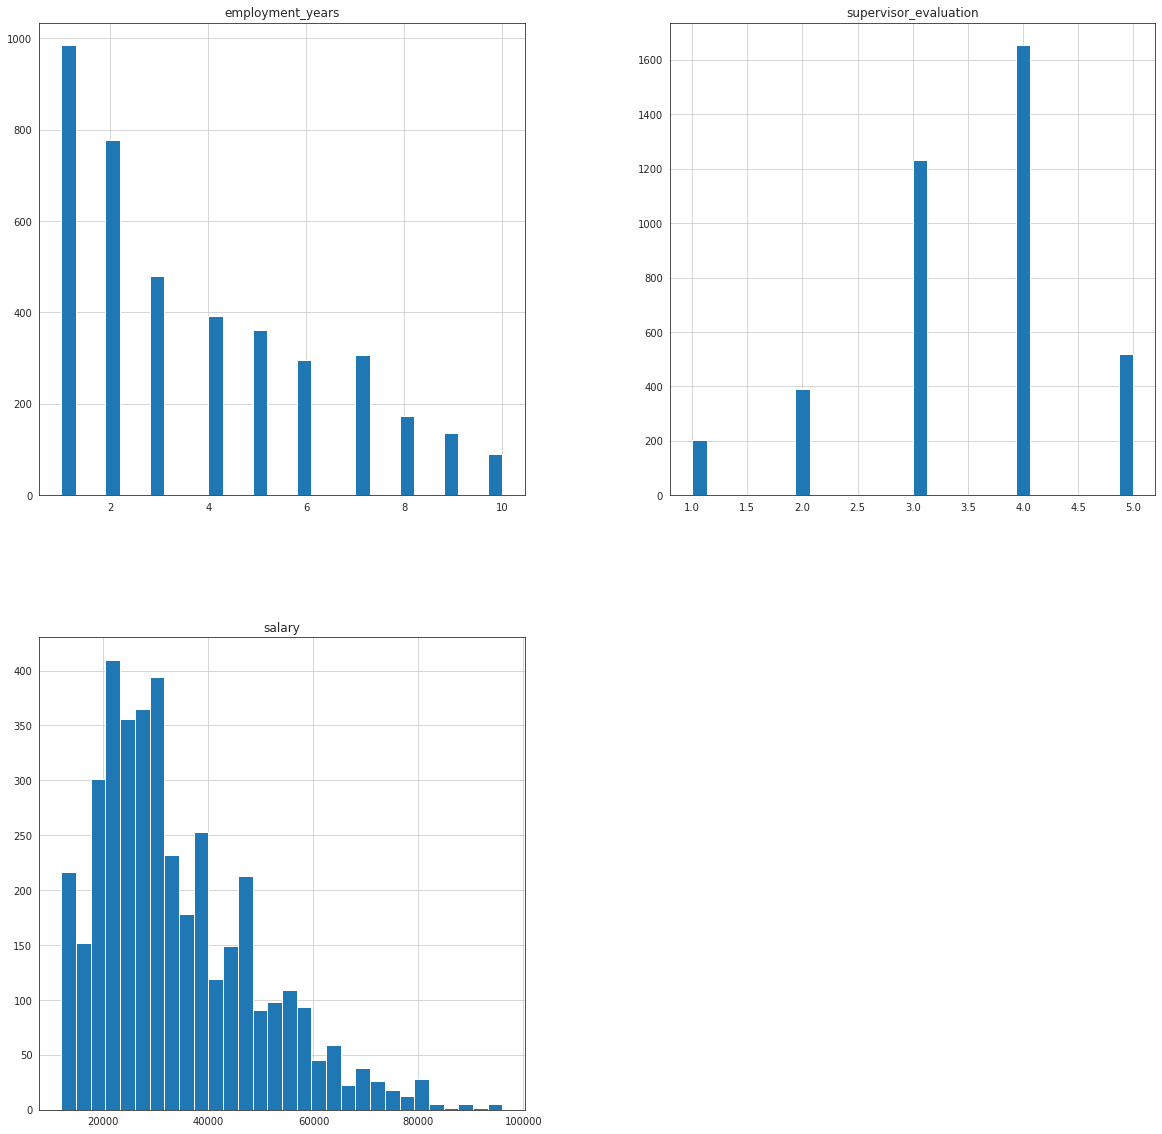

In [92]:
train_quit.drop('id', axis=1).hist(figsize=(20, 20),bins=30);

Выбросов не наблюдается.

Проверим категориальные признаки.

                                                dept                                                


,Количество
dept,
sales,1438
technology,928
purchasing,588
marketing,582
hr,464


                                               level                                                


,Количество
level,
junior,1949
middle,1694
sinior,357


                                              workload                                              


...

,Количество
last_year_promo,
no,3887
yes,113


                                        last_year_violations                                        


,Количество
last_year_violations,
no,3455
yes,545


                                                quit                                                


,Количество
quit,
no,2872
yes,1128


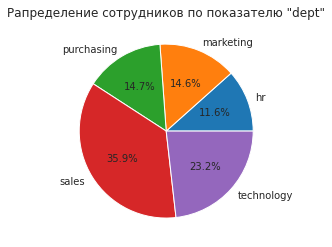

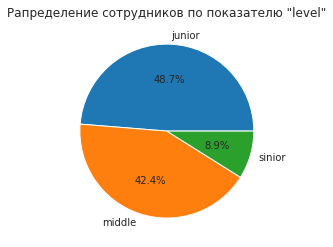

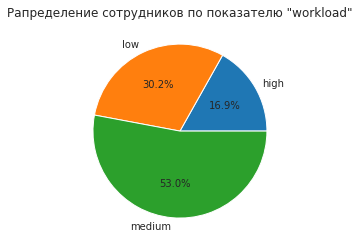

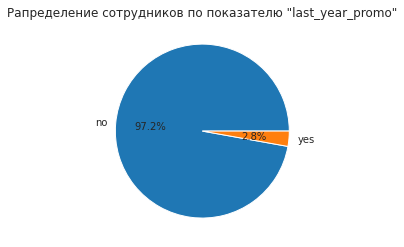

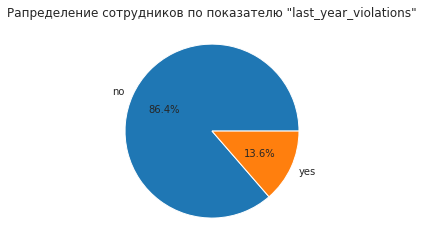

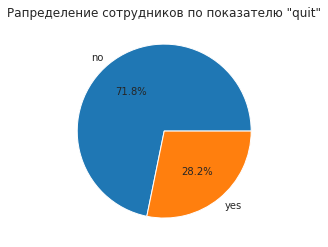

In [93]:
pie_market(train_quit)

**По итогам исследования категориальных признаков датасета train_quit выявлено, что 28,2% сотрудников уволились, а 71,8% все еще работает.**

Проанализируем количественные признаки.

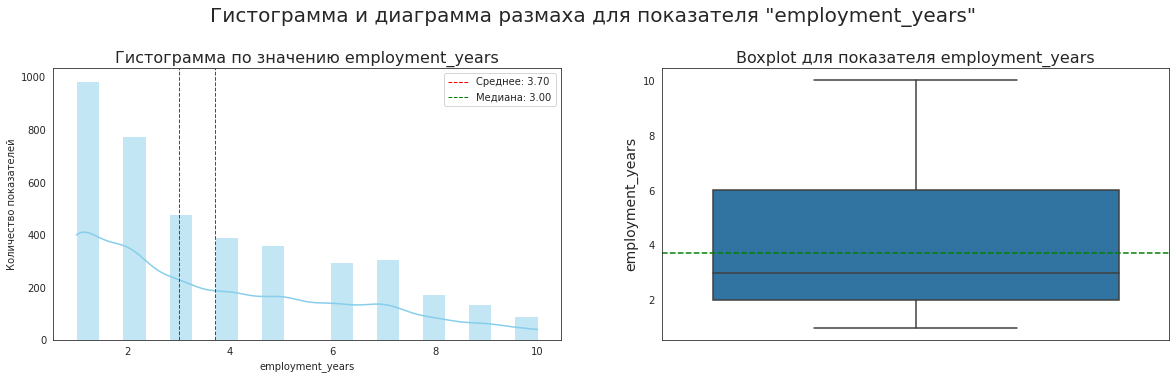

In [94]:
hist_plot(train_quit,'employment_years',20)

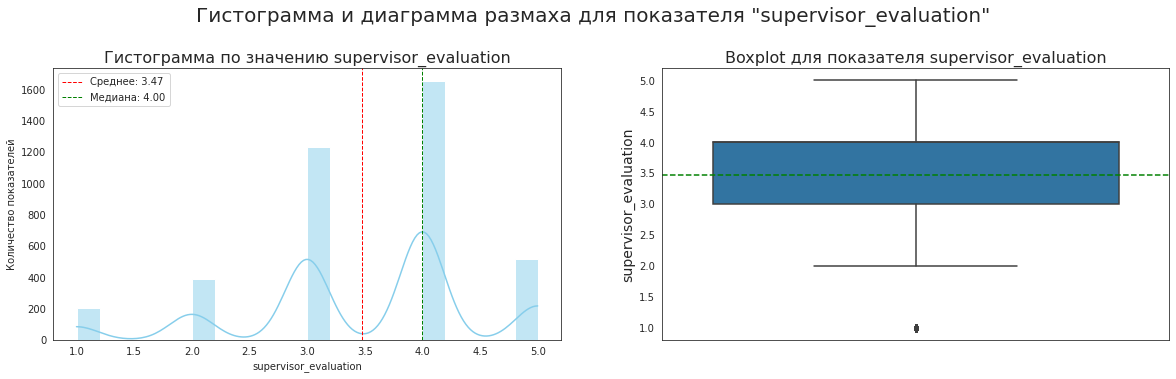

In [95]:
hist_plot(train_quit,'supervisor_evaluation',20)

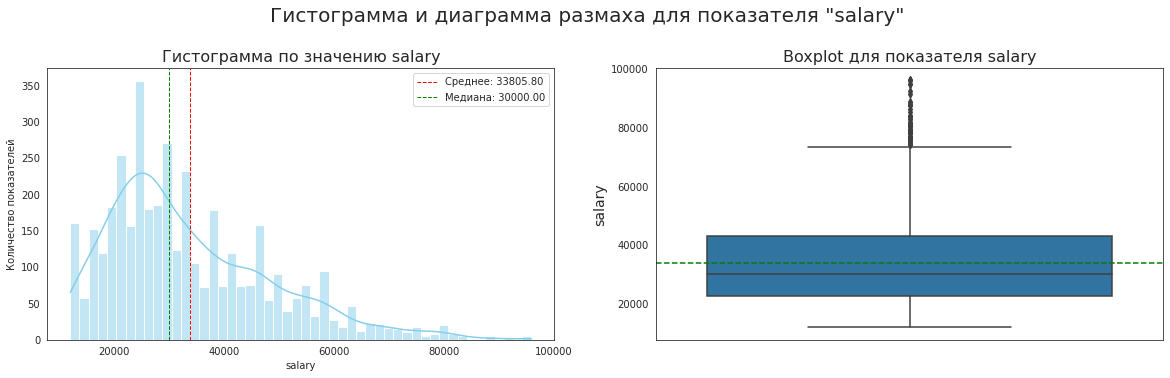

In [96]:
hist_plot(train_quit,'salary',50)

Пронализируем также распределение показателей в зависимости от увольнения.

In [97]:
train_quit_yes = train_quit.query('quit=="yes"')
train_quit_no = train_quit.query('quit=="no"')
print(train_quit_yes.shape)
print(train_quit_no.shape)

(1128, 10)
(2872, 10)


In [98]:
def yes_no_quit(data_yes,data_no):
    list_c = train_quit.drop('quit',axis=1).select_dtypes(include='object').columns.tolist()
    for name in list_c:
        table_yes = data_yes.pivot_table(index=name, values='id', aggfunc='count').reset_index()
        table_no = data_no.pivot_table(index=name, values='id', aggfunc='count').reset_index()

        fig, axs = plt.subplots(1, 2, figsize=(15, 5))      
        plt.suptitle (name, fontsize=20)
    
        plt.subplot(1, 2, 1)
        plt.title('Сотрудник уволится', fontsize=15)
        plt.pie(table_yes['id'].unique(), autopct='%1.1f%%',radius = 1)
    
        plt.subplot(1, 2, 2)
        plt.title('Сотрудник останется', fontsize=15)
        plt.pie(table_no['id'].unique(), autopct='%1.1f%%',radius = 1)
        plt.legend(title=name, loc="center right", bbox_to_anchor = (1.5,0,0.5,1),\
                   labels = table_no[name].unique())
    
    list_num = train_quit.drop(['id'], axis=1).\
    select_dtypes(include=['int64']).columns.tolist()
    for name in list_num:
        mean_yes = np.mean(data_yes[name])
        median_yes = np.median(data_yes[name])
        mean_no = np.mean(data_no[name])
        median_no = np.median(data_no[name])
        plt.figure(figsize=(7, 4))
        sns.histplot(data_yes[name], bins=70, color='orange', alpha=0.8,\
                     label='Сотрудник уволится', kde=True)
        plt.axvline(mean_yes, color='orange', linestyle='dashed', linewidth=1,\
                    label=f'Среднее для "Сотрудник уволится": {mean_yes:.2f}')
        plt.axvline(median_yes, color='red', linestyle='dashed', linewidth=1,\
                    label=f'Медиана для "Сотрудник уволится": {median_yes:.2f}');
        sns.histplot(data_no[name], bins=70, color='aquamarine', alpha=0.8,\
                     label='Сотрудник останется', kde=True)
        plt.axvline(mean_no, color='blue', linestyle='dashed', linewidth=1,\
                    label=f'Среднее для "Сотрудник останется": {mean_no:.2f}')
        plt.axvline(median_no, color='green', linestyle='dashed', linewidth=1,\
                    label=f'Медиана для "Сотрудник останется": {median_no:.2f}');
        plt.legend(title='Увольнение')
        plt.xlabel(name)
        plt.ylabel('Количество значений')
        plt.title('Гистограмма по значениям для "'+name+'"', fontsize=10);

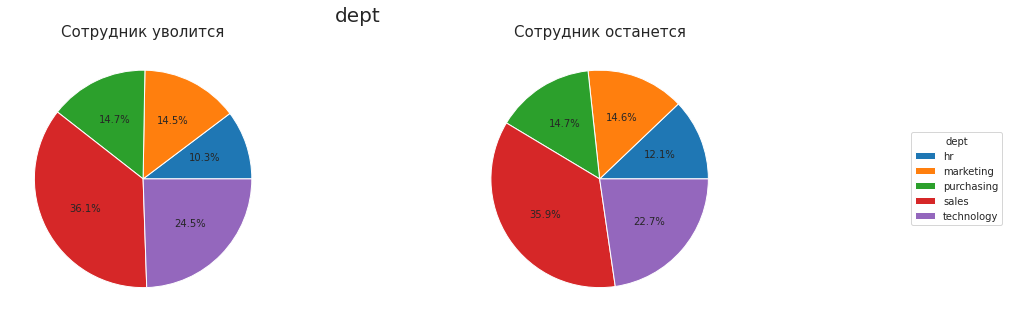

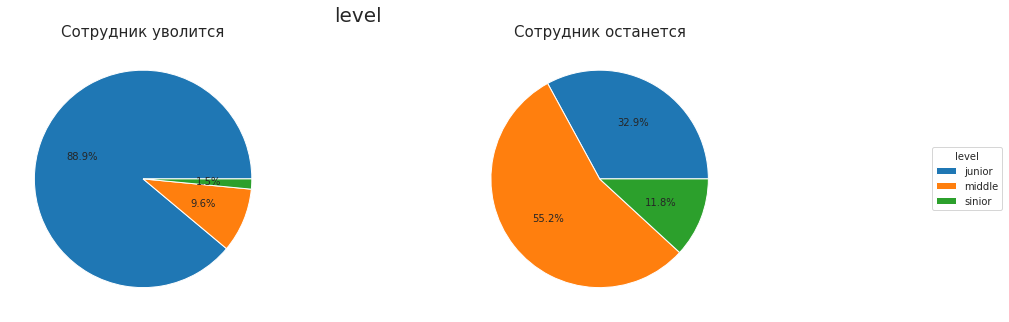

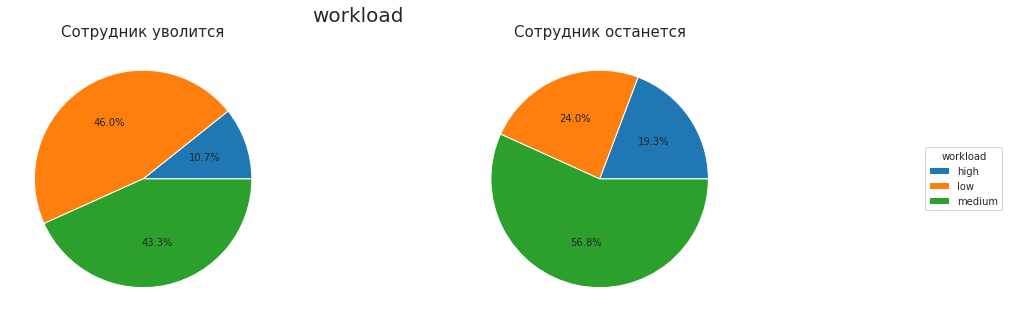

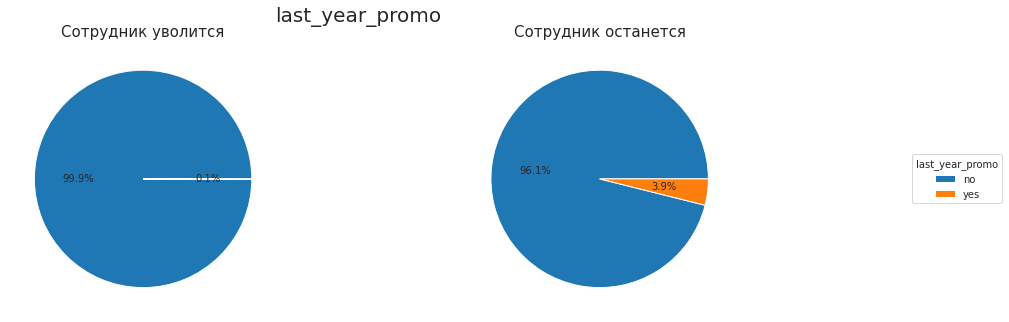

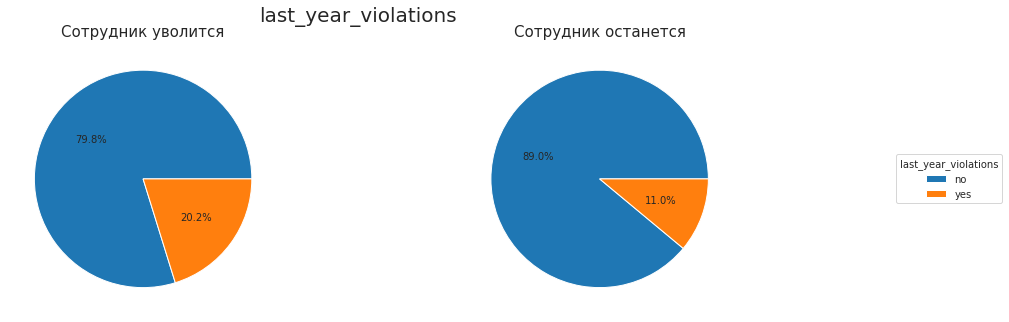

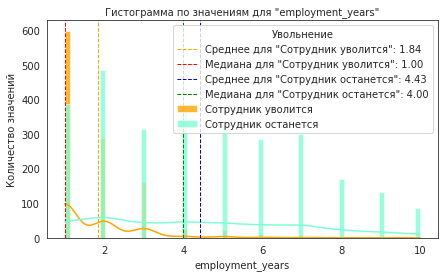

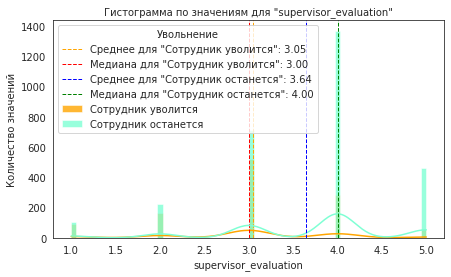

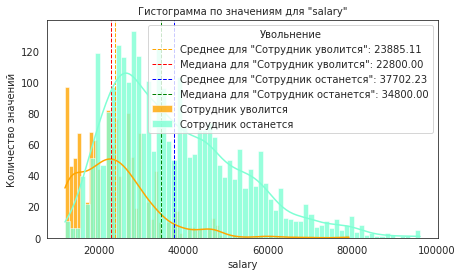

In [99]:
yes_no_quit(train_quit_yes,train_quit_no)

На тренировочной выборке отмечается следующее:
- признак департамента практически не влияет на увольнение/неувольнение сотрудника (распределение сотрудников у двух групп относительно сопоставимо);
- среди уволившихся наибольшее количество сотрудников относится к уровню ‘junior’ (88,9%), среди оставшихся – к уровню ‘middle’ (55,2%) (‘junior’ только 32,9%)
- среди уволившихся большее количество занимают сотрудники с низким уровнем загрузки (46%), практически такое же количество занимают сотрудники со средним уровнем загрузки (43,3%). Среди оставшихся 56,8% занимают сотрудники со средним уровнем загрузки.
- среди уволившихся только 0,1% сотрудников получили повышение в отличии от группы оставшихся сотрудников (3,9%)
- среди уволившихся сотрудников 20,2% нарушает трудовой договор, среди оставшихся доля составляет только 11%
- уволившиеся сотрудники гораздо меньше лет работают в компании согласно среднему и медианному значению
- уволившиеся сотрудники получали меньшие оценки качества работы от руководителей
- у уволившихся сотрудников в 1,5 раза меньше зарплата, чем у оставшихся сотрудников.


### Исследовательский анализ данных для датасета 'test_df_quit'

Частично анализ тестовых данных был уже проведен при анализе удовлетворенности сотрудников. Выведем значения еще раз для удобства.

In [100]:
test_df_quit.describe()

,id,employment_years,supervisor_evaluation,salary
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,552765.213500,3.666500,3.526500,34066.800000
std,253851.326129,2.537222,0.996892,15398.436729
min,100298.000000,1.000000,1.000000,12000.000000
25%,339052.000000,1.000000,3.000000,22800.000000
50%,550793.000000,3.000000,4.000000,30000.000000
75%,765763.750000,6.000000,4.000000,43200.000000
max,999029.000000,10.000000,5.000000,96000.000000


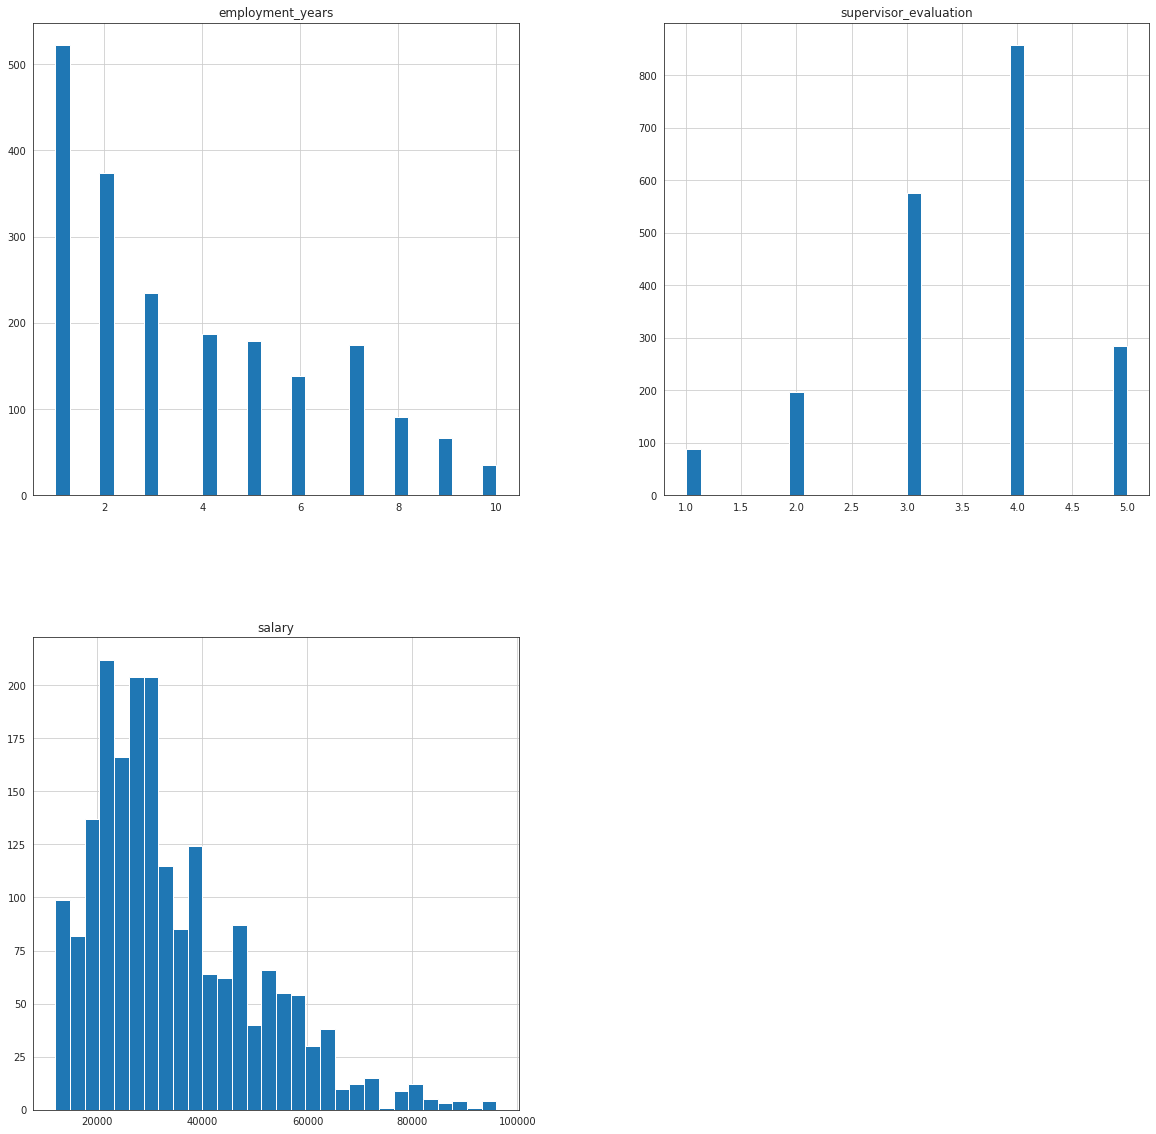

In [101]:
test_df_quit.drop('id', axis=1).hist(figsize=(20, 20),bins=30);

Выбросов не наблюдается.

                                                dept                                                


,Количество
dept,
sales,763
technology,455
marketing,279
purchasing,273
hr,227


                                               level                                                


,Количество
level,
junior,974
middle,854
sinior,171


                                              workload                                              


...

,Количество
last_year_promo,
no,1937
yes,63


                                        last_year_violations                                        


,Количество
last_year_violations,
no,1738
yes,262


                                                quit                                                


,Количество
quit,
no,1436
yes,564


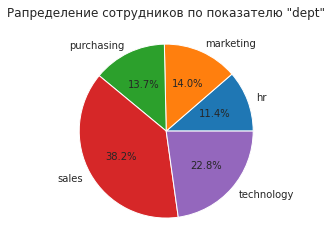

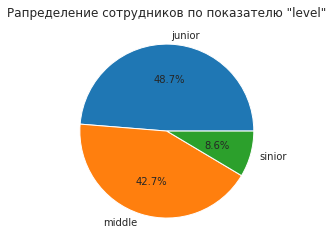

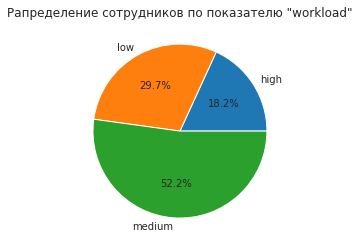

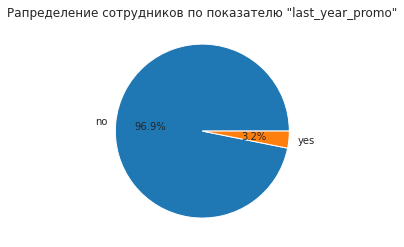

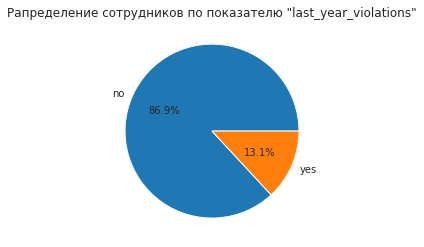

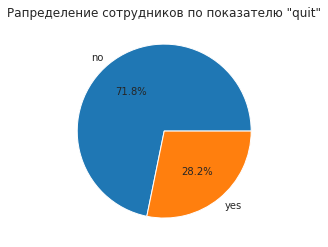

In [102]:
pie_market(test_df_quit)

**По итогам исследования категориальных признаков датасета test_df_quit выявлено, что 28,2% сотрудников уволились, а 71,8% все еще работает. Соответственно, не придется изменять тренировочный датасет для построения модели, т.к. соотношение данных совпадает с тестовыми**

Проанализируем количественные признаки.

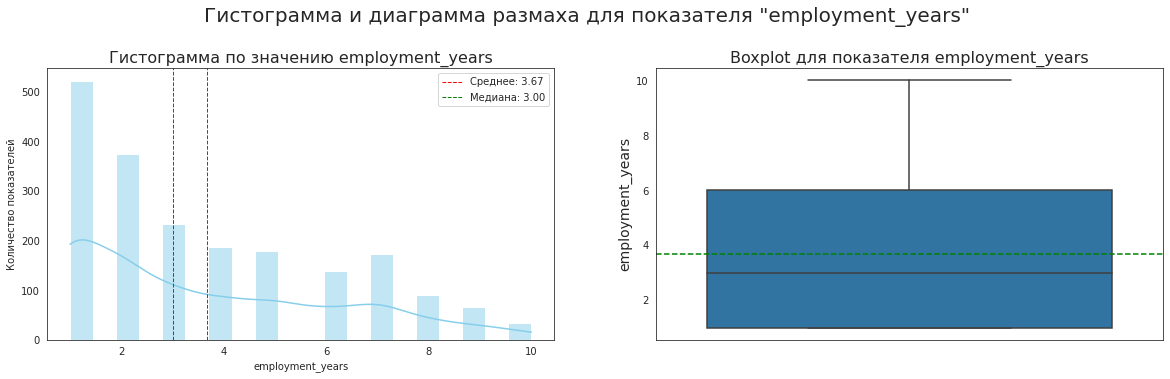

In [103]:
hist_plot(test_df_quit,'employment_years',20)

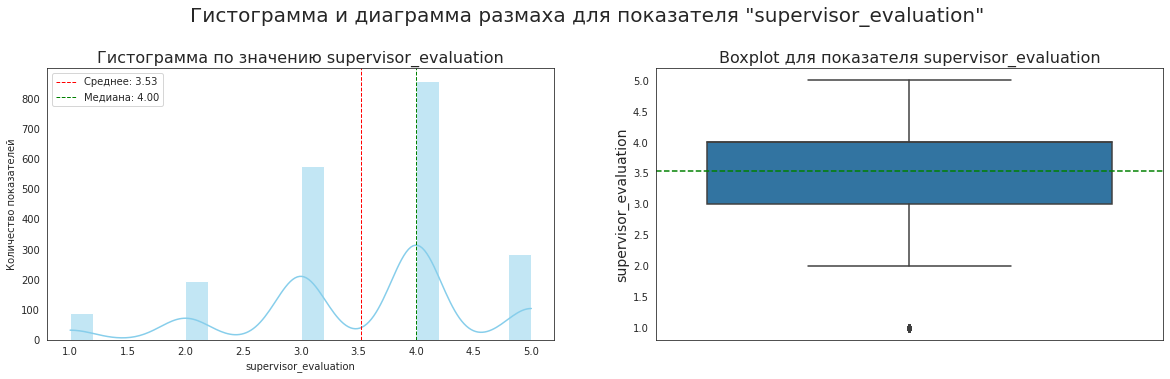

In [104]:
hist_plot(test_df_quit,'supervisor_evaluation',20)

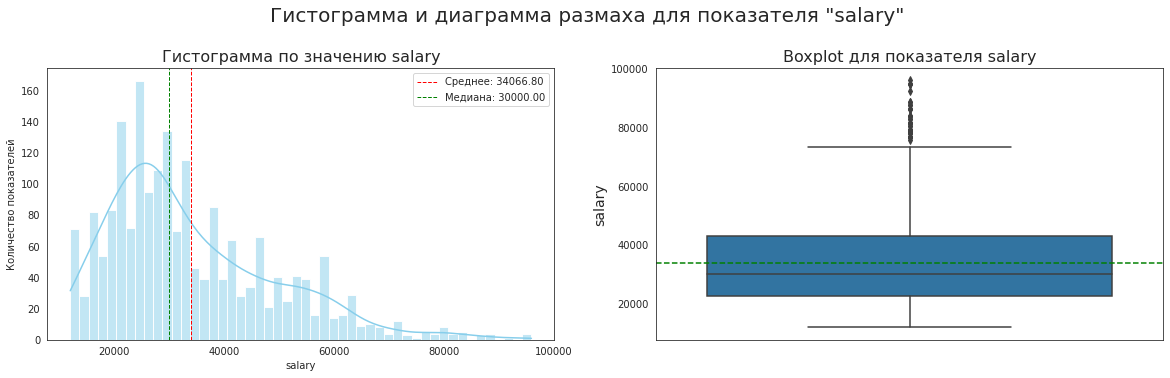

In [105]:
hist_plot(test_df_quit,'salary',50)

In [106]:
test_quit_yes = test_df_quit.query('quit=="yes"')
test_quit_no = test_df_quit.query('quit=="no"')
print(test_quit_yes.shape)
print(test_quit_no.shape)

(564, 10)
(1436, 10)


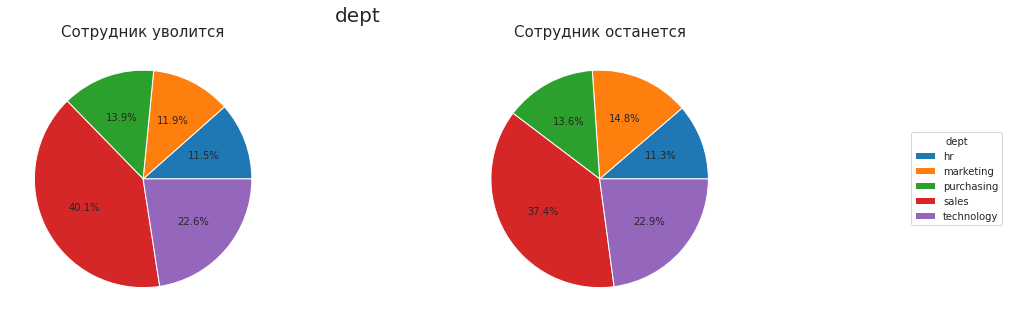

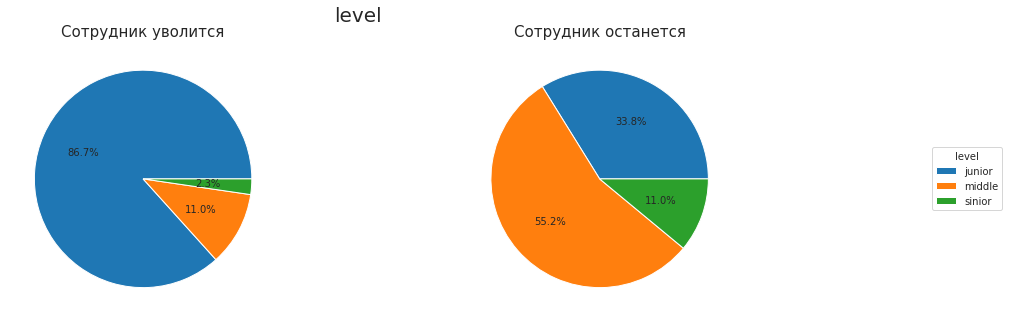

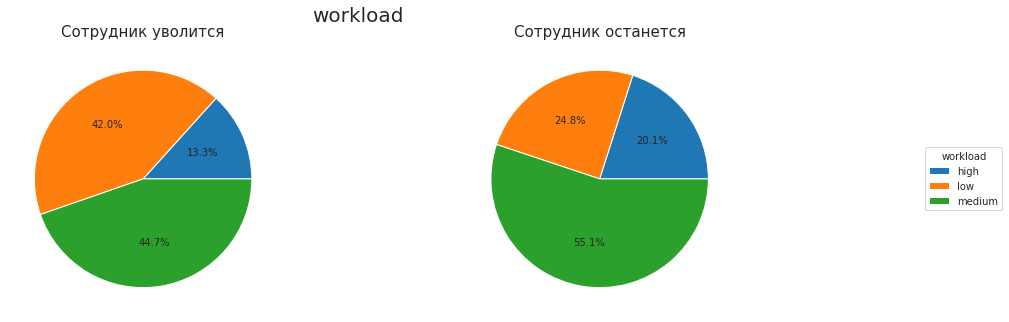

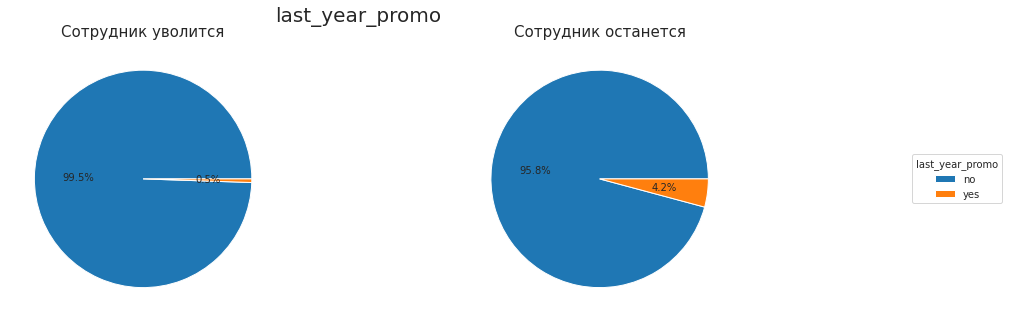

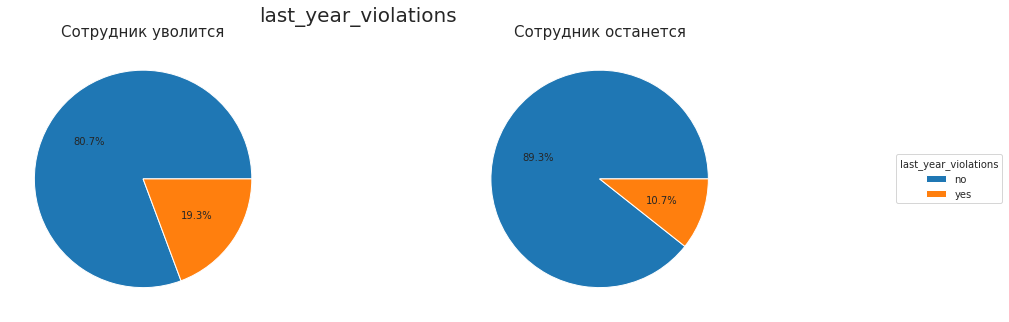

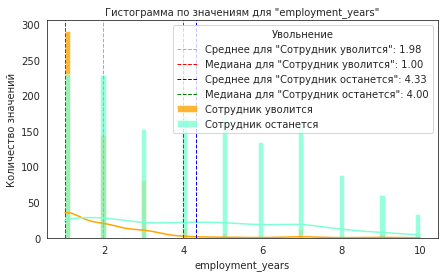

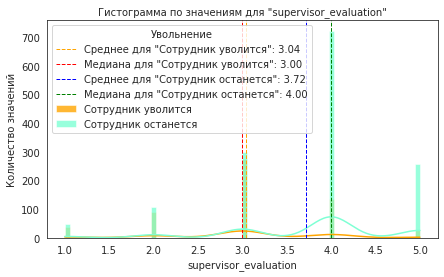

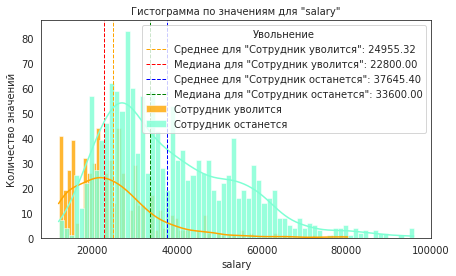

In [107]:
yes_no_quit(test_quit_yes,test_quit_no)

Картина на тестовых данных несколько изменилась:
    
- по департаменту данные относительно сопоставимы.
- среди уволившихся большее количество сотрудников имеют уровень 'junior' (86,7%), среди оставшихся 'middle' (55,2%)
- наибольшее количество уволившихся (44,7%) - сотрудники со средним уровнем загрузки. Немного отстают по объему (42%) сотрудники с низким уровнем загрузки. Среди оставшихся лидирует группа со средним уровнем загрузки (55,1%).
- среди уволившихся сотрудников только 0,5% получили повышение в отличии от группы оставшихся сотрудников (4,2%)
- среди уволившихся сотрудников большее количество нарушений трудового договора в отличии от оставшихся сотрудников
- уволившиеся сотрудники меньше времени проработали в компании в отличии от оставшихся сотрудников
- у уволившихся сотрудников меньшая оценка работы от руководителей в отличии от оставшихся сотрудников
- у уволившихся сотрудников в 1,5 раза меньше зарплата по сравнению с оставшейся группой

### Проверка утверждения, что уровень удовлетворённости сотрудника работой в компании влияет на то, уволится ли сотрудник

Аналитики утверждают, что уровень удовлетворённости сотрудника работой в компании влияет на то, уволится ли сотрудник.

Создадим новый датасет.

In [108]:
df_rate = test_df_rate[['id','job_satisfaction_rate']]
print(df_rate.shape)
display(df_rate.head())

(2000, 2)


,id,job_satisfaction_rate
0,485046,0.79
1,686555,0.72
2,467458,0.64
3,418655,0.60
4,789145,0.75


In [109]:
df_quit = test_df_quit[['id','quit']]
print(df_quit.shape)
display(df_quit.head())

(2000, 2)


,id,quit
0,485046,no
1,686555,no
2,467458,no
3,418655,no
4,789145,no


In [110]:
df_rate_quit = pd.merge(df_rate, df_quit, on='id')
display(df_rate_quit)

,id,job_satisfaction_rate,quit
0,485046,0.79,no
1,686555,0.72,no
2,467458,0.64,no
3,418655,0.60,no
4,789145,0.75,no
...,...,...,...
1995,393147,0.56,yes
1996,109582,0.14,yes
1997,305653,0.11,yes
1998,160233,0.43,no


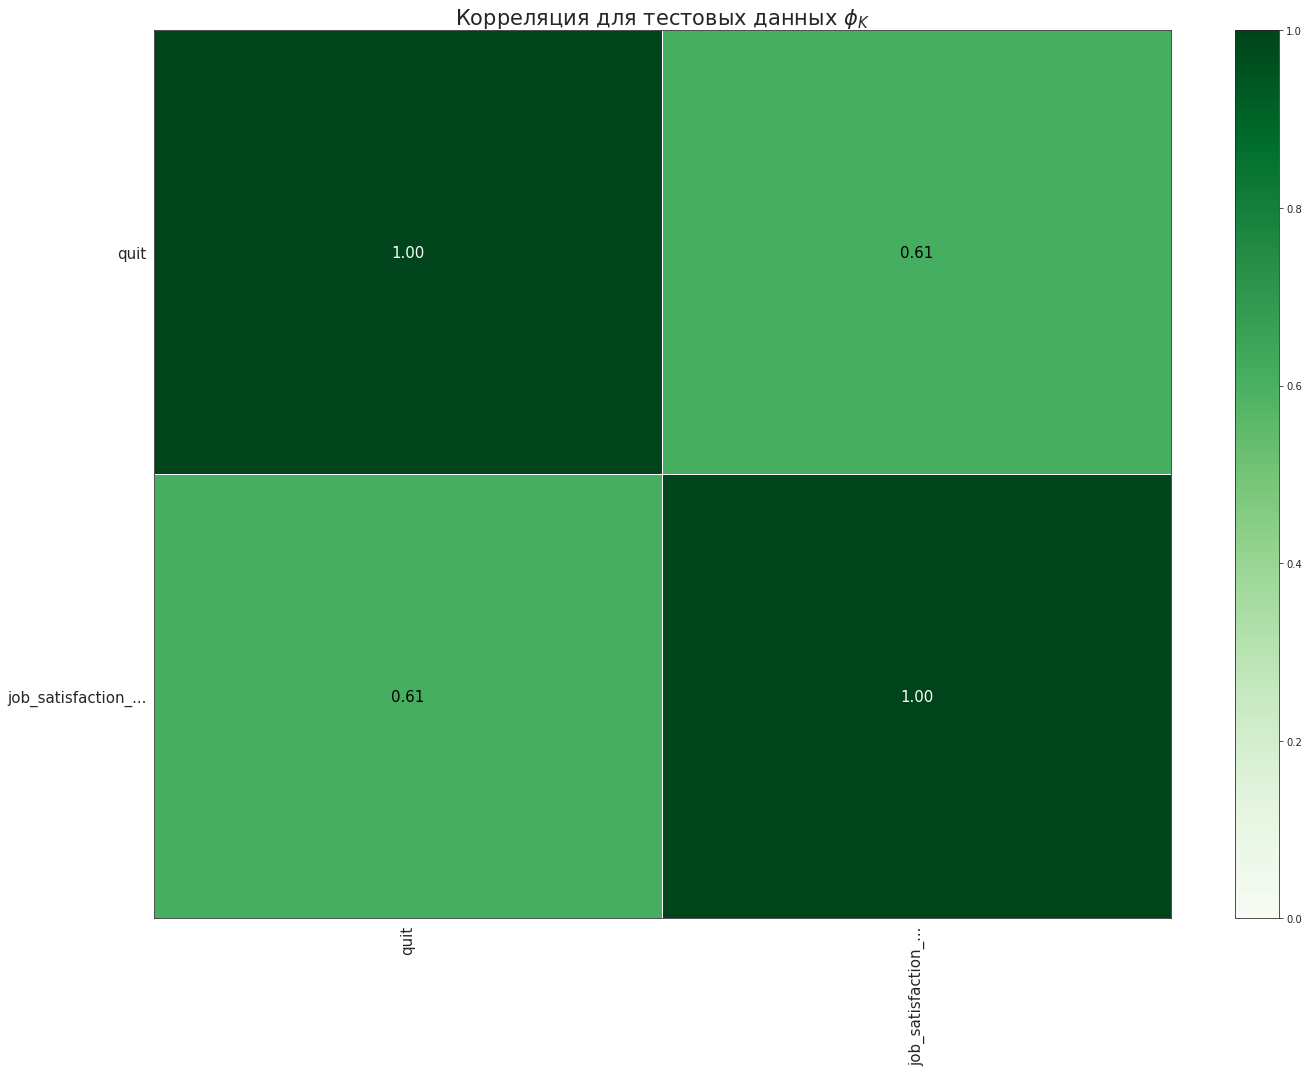

In [111]:
corr(df_rate_quit,r'Корреляция для тестовых данных $\phi_K$')

Для общей тестовой выборки не наблюдается ни только мультиколлинеарности, но и высокой корреляции.

Проанализируем показатели корреляции для каждой группы сотрудников (уволившихся и оставшихся).

In [112]:
df_rate_quit_yes = df_rate_quit.query('quit=="yes"')
df_rate_quit_no = df_rate_quit.query('quit=="no"')
print(df_rate_quit_yes.shape)
print(df_rate_quit_no.shape)

(564, 3)
(1436, 3)


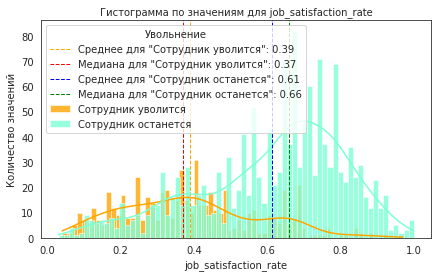

In [113]:
mean_yes = np.mean(df_rate_quit_yes['job_satisfaction_rate'])
median_yes = np.median(df_rate_quit_yes['job_satisfaction_rate'])
mean_no = np.mean(df_rate_quit_no['job_satisfaction_rate'])
median_no = np.median(df_rate_quit_no['job_satisfaction_rate'])
plt.figure(figsize=(7, 4))
sns.histplot(df_rate_quit_yes['job_satisfaction_rate'], bins=70, color='orange', alpha=0.8,\
                label='Сотрудник уволится', kde=True)
plt.axvline(mean_yes, color='orange', linestyle='dashed', linewidth=1,\
            label=f'Среднее для "Сотрудник уволится": {mean_yes:.2f}')
plt.axvline(median_yes, color='red', linestyle='dashed', linewidth=1,\
            label=f'Медиана для "Сотрудник уволится": {median_yes:.2f}');
sns.histplot(df_rate_quit_no['job_satisfaction_rate'], bins=70, color='aquamarine', alpha=0.8,\
                label='Сотрудник останется', kde=True)
plt.axvline(mean_no, color='blue', linestyle='dashed', linewidth=1,\
            label=f'Среднее для "Сотрудник останется": {mean_no:.2f}')
plt.axvline(median_no, color='green', linestyle='dashed', linewidth=1,\
            label=f'Медиана для "Сотрудник останется": {median_no:.2f}');
plt.legend(title='Увольнение')
plt.xlabel('job_satisfaction_rate')
plt.ylabel('Количество значений')
plt.title('Гистограмма по значениям для job_satisfaction_rate', fontsize=10);

Утверждение подтверждено, хотя мультиколлинеарности не наблюдается. Действительно у уволившихся сотрудников меньший уровень удовлетворенности работой, чем у оставшихся сотрудников.

<div style="border:solid green 2px; padding: 20px">
Вывод: На 9 шаге был проведен исследовательский анализ данных для задачи №2. Выяснено, что портрет уволившегося сотрудника выглядит следующим образом:

- сотрудник отдела продаж;
- уровень 'junior';
- с низкой/средней загрузкой работой;
- без повышения;
- с нарушениями трудового договора;
- работает в компании 1-3 года;
- с оценкой работы 3 и ниже;
- зарплата 22000-25000.
    
Подтверждено утверждение, что удовлетворенность работой влияет на увольнение.

## Шаг. Добавление нового входного признака для задачи №2

'job_satisfaction_rate' и 'quit' действительно связаны и было получено необходимое значение метрики в первой задаче. Добавим 'job_satisfaction_rate', предсказанный лучшей моделью первой задачи, к входным признакам второй задачи.

In [114]:
train_quit['job_satisfaction_rate'] = grid_search.best_estimator_.\
predict(train_quit.drop(['id','quit'],axis=1))
display(train_quit.head())

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
0,723290,sales,middle,high,2,no,no,4,54000,no,0.582916
1,814010,sales,junior,medium,2,no,no,4,27600,no,0.846667
2,155091,purchasing,middle,medium,5,no,no,1,37200,no,0.339556
3,257132,sales,junior,medium,2,no,yes,3,24000,yes,0.380000
4,910140,marketing,junior,medium,2,no,no,5,25200,no,0.690000


In [115]:
train_quit = train_quit.reindex(columns=['id',
                                         'dept',
                                         'level',
                                         'workload',
                                         'employment_years',
                                         'last_year_promo',
                                         'last_year_violations',
                                         'supervisor_evaluation',
                                         'salary',
                                         'job_satisfaction_rate',
                                         'quit'])

In [116]:
display(train_quit.head())

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,quit
0,723290,sales,middle,high,2,no,no,4,54000,0.582916,no
1,814010,sales,junior,medium,2,no,no,4,27600,0.846667,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,0.339556,no
3,257132,sales,junior,medium,2,no,yes,3,24000,0.380000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,0.690000,no


**<div style="border:solid green 2px; padding: 20px">
Вывод: На 10 шаге в датасет 'train_quit' был добавлен 'job_satisfaction_rate', предсказанный лучшей моделью первой задачи.**

## Шаг. Подготовка данных для задачи №2

In [117]:
# создаём списки с названиями признаков
ohe_columns = ['dept', 'last_year_promo','last_year_violations']
ord_columns = ['level','workload']
num_columns = train_quit.drop('id',axis=1).\
select_dtypes(include=['int64','float64']).columns.tolist()

In [118]:
train_quit_no_id = train_quit.drop('id',axis=1)

In [119]:
train_quit_no_id.shape

(4000, 10)

Проверим датасет на количество явных дубликатов.

In [120]:
print('Количество полных дубликатов ', train_quit_no_id.duplicated().sum())

Количество полных дубликатов  1413


Удалим данные дубликаты, т.к. они будут искажать модель.

In [121]:
train_quit_no_id = train_quit_no_id.drop_duplicates().reset_index(drop=True)
print('Количество полных дубликатов:',train_quit_no_id.duplicated().sum())

Количество полных дубликатов: 0


In [122]:
train_quit_no_id.shape

(2587, 10)

Объединим датасеты 'test_df_rate' и 'test_target_quit'.

In [123]:
test_rate_quit = pd.merge(test_df_rate, test_target_quit, on='id')

In [124]:
test_rate_quit.shape

(2000, 11)

In [125]:
# разбивка данных
X_train = train_quit_no_id.drop('quit',axis=1)
y_train = train_quit_no_id['quit']

X_test = test_rate_quit.drop(['id','quit'],axis=1)
y_test = test_rate_quit['quit']

In [126]:
def col_znach(y):
    unique_values_y, counts_y = np.unique(y, return_counts=True)
    print('Количество значений в датасете: ''\n')
    for value, count in zip(unique_values_y, counts_y):
        print(f"{value} {count}")

In [127]:
col_znach(y_train)

Количество значений в датасете: 

no 1932
yes 655


In [128]:
col_znach(y_test)

Количество значений в датасете: 

no 1436
yes 564


In [129]:
# создайте экземпляр класса LabelEncoder для кодирования целевого признака
label_encoder = LabelEncoder()

# трансформируем целевой признак
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.fit_transform(y_test)

In [130]:
col_znach(y_train)

Количество значений в датасете: 

0 1932
1 655


In [131]:
col_znach(y_test)

Количество значений в датасете: 

0 1436
1 564


In [132]:
# создаём пайплайн для подготовки признаков из списка ohe_columns:
#заполнение пропусков и OHE-кодирование
# SimpleImputer + OHE
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='error', sparse_output=False))
    ]
    )

# создаём пайплайн для подготовки признаков из списка ord_columns:
#заполнение пропусков и Ordinal-кодирование
# SimpleImputer + OE
ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(
                categories=[
                    ['junior', 'middle', 'sinior'],
                    ['low', 'medium','high']
                ], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

# создаём итоговый пайплайн: подготовка данных
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', [DecisionTreeClassifier(random_state=RANDOM_STATE),
                KNeighborsClassifier()])
])

**<div style="border:solid green 2px; padding: 20px">
Вывод: На 11 шаге были подготовлены данные в пайплайне. Для столбцов 'dept', 'last_year_promo','last_year_violations' был использован OneHotEncoder, для столбцов 'level','workload' - OrdinalEncoder.**

## Шаг. Обучение модели для задачи №2

In [133]:
param_grid = [
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 10),
        'models__max_features': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']  
    },
    
    # словарь для модели KNeighborsClassifier() 
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    }
]

In [134]:
grid_search = GridSearchCV(
    pipe_final, 
    param_grid=param_grid, 
    cv=5,
    # задайте метрику ROC-AUC
    scoring='roc_auc',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print('Лучшая модель и её параметры:\n\n', grid_search.best_estimator_)
print('Параметры лучшей модели:', grid_search.best_params_)
print('Метрика лучшей модели при применении кросс-валидации:', grid_search.best_score_)

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
                                       

In [135]:
prepare_data(X_train,X_test,StandardScaler())

In [136]:
#создание объекта для работы с моделью
model = DecisionTreeClassifier(random_state=42, max_depth=6, max_features=9)

#обучение модели на данных
model.fit(X_train_for_model, y_train)

# Предсказываем значения на тестовой выборке и выводим метрику ROC-AUC
probabilities = model.predict_proba(X_test_for_model)
probabilities_one = probabilities[:, 1]
print('Площадь ROC-кривой:', roc_auc_score(y_test, probabilities_one))

Площадь ROC-кривой: 0.9199855785377032


Критерий успеха для моделей был заложен: ROC-AUC ≥ 0.91 на тестовой выборке.

Проверим модель на адекватность.

In [137]:
# создайте и обучите DummyClassifier на тренировочных данных
# выполните предсказание на тестовой выборке
dummy_model = DummyClassifier(random_state=RANDOM_STATE)
dummy_model.fit(X_train, y_train)
dummy_model_preds = dummy_model.predict(X_test)
dummy_model_probas = dummy_model.predict_proba(X_test)[:,1]

# посчитайте и выведите метрику ROC-AUC
dummy_roc = roc_auc_score(y_test, dummy_model_probas)
print('ROC-AUC =', round(dummy_roc,2))

ROC-AUC = 0.5


Модель адекватна.

**<div style="border:solid green 2px; padding: 20px">
Вывод: На 12 шаге были обучены 2 модели: DecisionTreeRegressor, KNeighborsRegressor. Критерий успеха для моделей был заложен ROC-AUC ≥ 0.91 на тестовой выборке.
Для лучшей модели данный параметр составил 0.9199855785377032 ({'models': DecisionTreeClassifier(random_state=42), 'models__max_depth': 6, 'models__max_features': 9, 'preprocessor__num': StandardScaler()})**

## Шаг. Анализ важности признаков для задачи №2

### Анализ важности признаков самой моделью

У объекта «DecisionTreeClassifier» отсутствует атрибут «coef_». Отсутсвует возможность оценить важность признаков.

### Подбор важных признаков с применение SelectKBest()

In [138]:
X_train_for_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2587 entries, 0 to 2586
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   dept_marketing            2587 non-null   float64
 1   dept_purchasing           2587 non-null   float64
 2   dept_sales                2587 non-null   float64
 3   dept_technology           2587 non-null   float64
 4   last_year_promo_yes       2587 non-null   float64
 5   last_year_violations_yes  2587 non-null   float64
 6   level                     2587 non-null   float64
 7   workload                  2587 non-null   float64
 8   employment_years          2587 non-null   float64
 9   supervisor_evaluation     2587 non-null   float64
 10  salary                    2587 non-null   float64
 11  job_satisfaction_rate     2587 non-null   float64
dtypes: float64(12)
memory usage: 242.7 KB


In [139]:
#создадим списки показателей
k = [] #количество признаков
roc_auc_train = [] #показатель roc-auc для тренировочной выборки
roc_auc_test = [] #показатель roc-auc для тестовой выборки
accs = [] #показатель accuracy
f_score = [] #показатель f1-score
priz_names = [] #перечень признаков


for i in range(1, 13):
    #селектор
    selector = SelectKBest(f_classif, k=i)

    #применяем SelectKBest к набору тренировочных данных
    X_train_select = selector.fit_transform(X_train_for_model, y_train)
    
    #применяем SelectKBest к набору тестовых данных
    X_test_select = selector.transform(X_test_for_model)
    
    #обучаем модель на отобранных признаках
    model.fit(X_train_select, y_train)
    
    #применяем модель к тестовым данным
    y_pred_select = model.predict(X_test_select)
    
    index = selector.get_support(indices=True)
    
    k.append(i)
    
    #выводим значения roc-auc
    roc_auc_train.append(round(cross_val_score(model, X_train_select, y_train,\
                                               scoring='roc_auc').mean(), 3))  
    probabilities = model.predict_proba(X_test_select)
    probabilities_one = probabilities[:, 1]
    roc_auc_test.append(round(roc_auc_score(y_test, probabilities_one), 3))
    
    #выводим accuracy
    accs.append(round(accuracy_score(y_test, y_pred_select), 3))
    
    #выводим f1-score
    f_score.append(round(f1_score(y_test, y_pred_select, pos_label=1), 3))
              
    #извлекаем названия выбранных признаков из исходного датасета
    feature_names = X_train_for_model.columns[index].tolist()
    
    priz_names.append(feature_names)

#создаем отдельный датасет для метрик
metric = pd.DataFrame({'k': k,
                       'ROC_AUC_train': roc_auc_train,
                       'ROC_AUC_test': roc_auc_test,
                       'Accuracy': accs,
                       'f1_score': f_score,
                       'Признаки': priz_names
                       
                       }
                     )
              
display(metric)

,k,ROC_AUC_train,ROC_AUC_test,Accuracy,f1_score,Признаки
0,1,0.806,0.763,0.719,0.635,[level]
1,2,0.858,0.816,0.746,0.649,"[level, employment_years]"
2,3,0.854,0.846,0.788,0.669,"[level, employment_years, salary]"
3,4,0.885,0.914,0.875,0.797,"[level, employment_years, salary, job_satisfac..."
4,5,0.882,0.913,0.875,0.798,"[level, employment_years, supervisor_evaluatio..."
5,6,0.893,0.922,0.920,0.856,"[level, workload, employment_years, supervisor..."
6,7,0.894,0.922,0.922,0.860,"[last_year_violations_yes, level, workload, em..."
7,8,0.895,0.923,0.924,0.862,"[last_year_promo_yes, last_year_violations_yes..."
8,9,0.893,0.923,0.924,0.862,"[dept_purchasing, last_year_promo_yes, last_ye..."
9,10,0.893,0.920,0.902,0.835,"[dept_purchasing, dept_sales, last_year_promo_..."


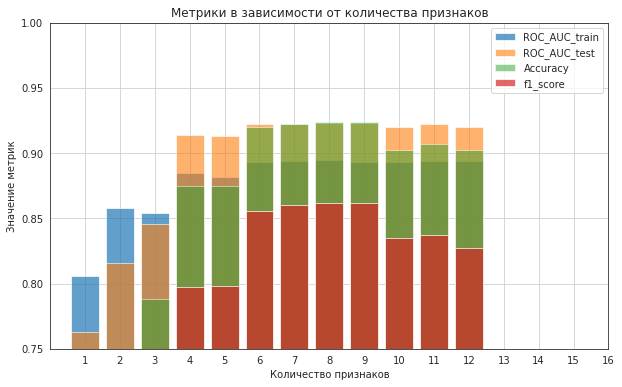

In [140]:
# Создаем гистограмму
plt.figure(figsize=(10, 6))

# Гистограмма ROC-AUC на тренировочной выборке
plt.bar(metric['k'], metric['ROC_AUC_train'], label='ROC_AUC_train', alpha=0.7)

# Гистограмма ROC-AUC на тестовой выборке
plt.bar(metric['k'], metric['ROC_AUC_test'], label='ROC_AUC_test', alpha=0.6)

# Гистограмма Accuracy
plt.bar(metric['k'], metric['Accuracy'], label='Accuracy', alpha=0.5)

# Гистограмма F1-меры
plt.bar(metric['k'], metric['f1_score'], label='f1_score', alpha=0.7)

# Добавляем заголовок
plt.title('Метрики в зависимости от количества признаков')

# Добавляем метки осей
plt.xlabel('Количество признаков')
plt.ylabel('Значение метрик')

# Устанавливаем лимиты для оси x
plt.xticks(range(1, 17))

# Устанавливаем лимиты для оси y
plt.ylim(0.75, 1)

# Добавляем легенду
plt.legend()

# Показываем гистограмму
plt.grid(True)
plt.show()

Выводим максимальные значения метрик:

In [141]:
max_ROC_AUC_test = metric['ROC_AUC_test'].max()
max_acc = metric['Accuracy'].max()
max_f1 = metric['f1_score'].max()
print('максимальная ROC-AUC_test:',max_ROC_AUC_test)
print('максимальная Accuracy:',max_acc)
print('максимальная f1 - score:',metric['f1_score'].max())

максимальная ROC-AUC_test: 0.923
максимальная Accuracy: 0.924
максимальная f1 - score: 0.862


In [142]:
best_metric = metric.query('ROC_AUC_test==@max_ROC_AUC_test')
display(best_metric)

,k,ROC_AUC_train,ROC_AUC_test,Accuracy,f1_score,Признаки
7,8,0.895,0.923,0.924,0.862,"[last_year_promo_yes, last_year_violations_yes..."
8,9,0.893,0.923,0.924,0.862,"[dept_purchasing, last_year_promo_yes, last_ye..."


In [143]:
best_metric['Признаки'].tolist()

[['last_year_promo_yes',
  'last_year_violations_yes',
  'level',
  'workload',
  'employment_years',
  'supervisor_evaluation',
  'salary',
  'job_satisfaction_rate'],
 ['dept_purchasing',
  'last_year_promo_yes',
  'last_year_violations_yes',
  'level',
  'workload',
  'employment_years',
  'supervisor_evaluation',
  'salary',
  'job_satisfaction_rate']]

### Проверка permutation importance

/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/opt/conda/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWar

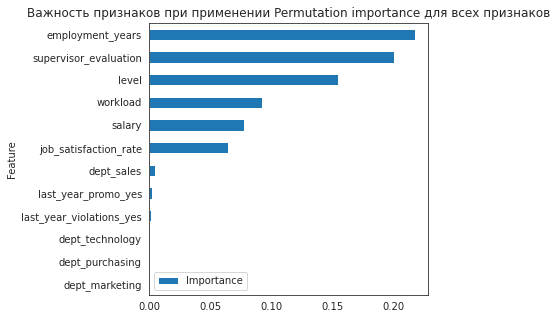

In [144]:
def custom_f1(model, X, y):
    y_pred = model.predict(X)
    score = f1_score(y, y_pred)
    return score

result = permutation_importance(model, X_test_for_model, y_test, scoring=custom_f1)

feature_importance = pd.DataFrame({'Feature': X_test_for_model.columns,\
                                   'Importance': result['importances_mean']})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
sns.set_style('white')
feature_importance.plot(x='Feature', y='Importance', kind='barh',\
                        figsize=(5, 5)).\
set_title("Важность признаков при применении Permutation importance для всех признаков");

**Permutation importance включил в топ-5 важных признаков:**
    
- продолжительность работы на компанию
- оценка сотрудника
- уровень сотрудника
- загрузка сотрудника
- зарплата

Наименее влияющим признаком признана работа на департамент маркетинга.

### Анализ SHAP-значений

Однозначную оценку вклада признака в каждый прогноз показывают значения Шепли, их оценивают методом **SHAP (SHapley Additive exPlanations)**. Он вычисляет, как отдельный признак помог присвоить модели итоговое значение целевого.

  0%|          | 0/2000 [00:00<?, ?it/s]

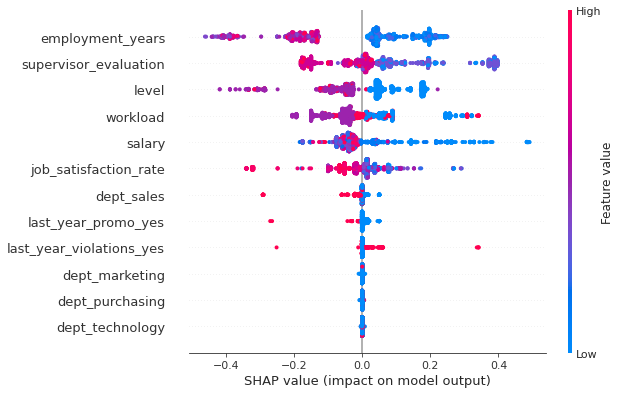

In [145]:
sample = shap.sample(X_train_for_model, nsamples=10, random_state=RANDOM_STATE)

# Инициализируем KernelExplainer с суммарным фоном
explainer = shap.KernelExplainer(model.predict, sample)

# Вычисляем SHAP значения
shap_values = explainer(X_test_for_model)

# Визуализируем SHAP значений с помощью графика beeswarm
shap.plots.beeswarm(shap_values, max_display=16);

- значения слева от центральной вертикальной линии — это negative класс (0), справа — positive (1)
- чем толще линия на графике, тем больше таких точек наблюдения
- чем краснее точки на графике, тем выше значения признака в ней

**Анализ SHAP-значений вывел топ-5 признаков, среди которых:**

- продолжительность работы на компанию (чем выше показатель, тем больше вероятность отнесения к классу "Сотрудник останется"(0))
- оценка работы сотрудника (чем выше показатель, тем больше вероятность отнесения к классу "Сотрудник останется"(0))
- уровень сотрудника (чем выше показатель, тем больше вероятность отнесения к классу "Сотрудник останется"(0))
- загрузка сотрудника (чем ниже показатель, тем больше вероятность отнесения к классу "Сотрудник останется"(0))
- зарплата (чем выше показатель, тем больше вероятность отнесения к классу "Сотрудник останется"(0))

Наименее влияющим признаком признана работа на департамент маркетинга.

<div style="border:solid green 2px; padding: 20px">
Вывод: На 13 шаге были получены данные о важности признаков с применением выбранной модели, Permutation importance и анализа SHAP-значений. Наиболее важными были признаны:
    
- продолжительность работы на компанию
- оценка сотрудника
- уровень сотрудника
- загрузка сотрудника    
- зарплата    
    
Наименее влияющими признаками признана работа на департамент маркетинга.

## Шаг. Оформление выводов для задачи №2

<div style="border:solid green 2px; padding: 20px">
Вывод: по итогам задачи №2 были выполнены следующие этапы:
    
- загружены файлы с данными;
- проведена обработка данных, пропуски не заполнялись (были заполнены в пайплайне);
- проведен исследовательский анализ данных;
- проведен корреляционный анализ;
- были подготовлены признаки в пайплайне;
- были обучены 2 модели: DecisionTreeClassifier(), KNeighborsClassifier(). Критерий успеха для моделей был заложен: ROC-AUC ≥ 0.91 на тестовой выборке. Для лучшей модели данный параметр составил 0.9199855785377032 ({'models': DecisionTreeClassifier(random_state=42), 'models__max_depth': 6, 'models__max_features': 9, 'preprocessor__num': StandardScaler()}). SelectKBest() продемонстрировал, что использование 8-9 признаков результат метрики достигает 0,923.

    
- был проведен анализ важности признаков. Наиболее значимыми признаками стали:
    - продолжительность работы на компанию
    - оценка сотрудника
    - уровень сотрудника
    - загрузка сотрудника    
    - зарплата    
    
  Наименее влияющим признаком признан работа на департамент маркетинга.
    
- был выведен портрет сотрудника, готового к увольнению:
    
    - сотрудник отдела закупок;
    - уровень 'junior';
    - с низкой/средней загрузкой работой;
    - без повышения;
    - с нарушениями трудового договора;
    - работает в компании 1-3 года;
    - с оценкой работы 3 и ниже;
    - зарплата 22000-25000.
    
    
Комментарии для заказчика:
    

- обратить внимание на сотрудников, которые меньше времени находятся в компании (либо люди не могут влиться в коллектив, либо взаимодействие между старыми и новыми сотрудниками не налажено)
- обратить внимание на сотрудников с меньшей заработной платой. Возможно, стоит пересмотреть условия договора в разрезе заработной платы.
- возможно есть сотрудники 'junior' и 'middle', которых можно повысить.
- стоит обратить внимание на критическое отношение к оценкам работников (пересмотреть ранжирование оценок, выяснить причины плохой работы (безалберность и безответсвенность или последствия иных условий работы)
- обратить внимание на загрузку сотрудников, т.к. недозагрузка/перегрузка сотрудника приводят к решению уволиться.    

# Общий вывод

<div style="border:solid green 2px; padding: 20px">
Вывод: по итогам проекта были выполнены следующие этапы для каждой задачи:
    
- загружены файлы с данными;
- проведена обработка данных, пропуски не заполнялись (были заполнены в пайплайне);
- проведен исследовательский анализ данных;
- проведен корреляционный анализ;
- были подготовлены признаки в пайплайне;
- были обучены 2-3 модели для каждой задачи;
- был проведен анализ важности признаков;
- предоставлены комментарии для заказчика по улучшению ситуации для каждой задачи.